# 30-Day Hospital Readmission Risk Prediction: A SQL-Driven and Explainable Machine Learning Approach


**Title of ML project : 30-Day Hospital Readmission Risk Prediction: A SQL-Driven and Explainable Machine Learning Approach**

**Name: Sruthi T S**

**Organization: Entri Elevate**

**Date: 21/08/2026**

## Problem Statement

Hospital readmissions within 30 days of discharge represent a significant
challenge for healthcare systems, both clinically and financially. Under
the U.S. Centers for Medicare & Medicaid Services' Hospital Readmissions
Reduction Program, hospitals face financial penalties for excess
readmissions, making early identification of at-risk patients a priority
for care management and discharge planning. Despite established clinical
guidelines for post-discharge care, many patients — particularly those
with chronic conditions like diabetes — are readmitted due to inconsistent
follow-up, inadequate risk stratification, or gaps in identifying high-risk
patients before discharge. This project addresses the need for a
data-driven approach to flag patients at elevated readmission risk, using
structured hospital encounter data.

## Objective

The objective of this project is to build an end-to-end machine learning
pipeline that predicts whether a patient will be readmitted to the
hospital within 30 days of discharge, using structured clinical and
administrative data. Specifically, this project aims to:
1. Extract and structure hospital data using a relational SQL approach.
2. Clean, analyze, and engineer features for machine learning.
3. Build and evaluate ML models while addressing class imbalance.
4. Apply SHAP explainability to identify factors influencing readmission risk.
5. Deploy the final model as an interactive Streamlit application providing risk estimates and patient-level explanations.

## Data Description

This project uses the **Diabetes 130-US Hospitals dataset (1999–2008)**,
sourced from the UCI Machine Learning Repository. The dataset represents
ten years of clinical care data from 130 US hospitals and integrated
delivery networks, comprising **101,766 hospital encounters** for patients
diagnosed with diabetes.

The dataset includes demographic, admission, clinical, diagnosis, procedure, and medication-related features. The original three-class readmitted variable was converted into a binary target, readmitted_30d, indicating whether readmission occurred within 30 days.

**Data source:** UCI Machine Learning Repository — Diabetes 130-US Hospitals.

**Limitation:** The dataset covers 1999–2008 and uses ICD-9 coding. Therefore, the project is intended as a methodology and portfolio demonstration, not a production-ready clinical tool.

In [ ]:
# ---------------------------------------------------------
# STARTUP BLOCK — This block reconnects Google Drive and reloads the saved model and project files whenever the notebook is reopened,
# allowing the analysis to continue without retraining.
# ---------------------------------------------------------
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

save_path = '/content/drive/My Drive/Dataset/Hospital readmission/'

rf_tuned = joblib.load(save_path + 'rf_tuned_model.pkl')
feature_columns = joblib.load(save_path + 'feature_columns.pkl')
final_threshold = joblib.load(save_path + 'final_threshold.pkl')
scaler = joblib.load(save_path + 'scaler.pkl')
default_row = joblib.load(save_path + 'default_row.pkl')

print("Environment restored successfully:")
print("- rf_tuned:", type(rf_tuned))
print("- feature_columns:", len(feature_columns))
print("- final_threshold:", final_threshold)
print("- default_row length:", len(default_row))

Mounted at /content/drive
Environment restored successfully:
- rf_tuned: <class 'imblearn.pipeline.Pipeline'>
- feature_columns: 117
- final_threshold: 0.32
- default_row length: 117


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Data Extraction (SQL)
### 1.1. Load the raw dataset

In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/My Drive/Dataset/Hospital readmission/diabetic_data.csv')
df.shape

(101766, 50)

In [ ]:
print(df.columns.tolist())
df.info()

['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------     

### 1.2. Split into 4 relational tables

In [ ]:
# 1. PATIENTS table — one row per unique patient (static attributes)
# drop_duplicates keeps the FIRST occurrence of each patient_nbr,
# since the same patient can have multiple hospital encounters
patients = df[['patient_nbr', 'race', 'gender', 'age', 'weight']] \
    .drop_duplicates(subset='patient_nbr') \
    .reset_index(drop=True)

# 2. ENCOUNTERS table — one row per hospital visit (admission details + target variable)
encounters = df[['encounter_id', 'patient_nbr', 'admission_type_id',
                  'discharge_disposition_id', 'admission_source_id',
                  'time_in_hospital', 'payer_code', 'medical_specialty',
                  'readmitted']].reset_index(drop=True)

# 3. DIAGNOSES table — diagnosis codes per encounter
diagnoses = df[['encounter_id', 'diag_1', 'diag_2', 'diag_3',
                 'number_diagnoses']].reset_index(drop=True)

# 4. PROCEDURES_MEDS table — labs, procedures, and FULL medication info per encounter
medication_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
                    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
                    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
                    'miglitol', 'troglitazone', 'tolazamide', 'examide',
                    'citoglipton', 'insulin', 'glyburide-metformin',
                    'glipizide-metformin', 'glimepiride-pioglitazone',
                    'metformin-rosiglitazone', 'metformin-pioglitazone']

procedures_meds = df[['encounter_id', 'num_lab_procedures', 'num_procedures',
                       'num_medications', 'number_outpatient', 'number_emergency',
                       'number_inpatient', 'diabetesMed', 'change',
                       'A1Cresult', 'max_glu_serum'] + medication_cols].reset_index(drop=True)

print("\npatients:", patients.shape)
print("encounters:", encounters.shape)
print("diagnoses:", diagnoses.shape)
print("procedures_meds:", procedures_meds.shape)



patients: (71518, 5)
encounters: (101766, 9)
diagnoses: (101766, 5)
procedures_meds: (101766, 34)


### 1.3. Load all 4 tables into SQLite database

In [ ]:
conn = sqlite3.connect('hospital_readmission.db')

patients.to_sql('patients', conn, if_exists='replace', index=False)
encounters.to_sql('encounters', conn, if_exists='replace', index=False)
diagnoses.to_sql('diagnoses', conn, if_exists='replace', index=False)
procedures_meds.to_sql('procedures_meds', conn, if_exists='replace', index=False)

print("\nAll 4 tables loaded into hospital_readmission.db")

# Verify tables exist in the database
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
print("Tables in database:", cursor.fetchall())



All 4 tables loaded into hospital_readmission.db
Tables in database: [('patients',), ('encounters',), ('diagnoses',), ('procedures_meds',)]


### 1.4. JOIN — reconstruct one usable dataset from the 4 tables

In [ ]:
query = """
SELECT
    e.encounter_id, e.patient_nbr,
    p.race, p.gender, p.age, p.weight,
    e.admission_type_id, e.discharge_disposition_id, e.admission_source_id,
    e.time_in_hospital, e.payer_code, e.medical_specialty,
    d.diag_1, d.diag_2, d.diag_3, d.number_diagnoses,
    pm.*,
    e.readmitted
FROM encounters e
JOIN patients p ON e.patient_nbr = p.patient_nbr
JOIN diagnoses d ON e.encounter_id = d.encounter_id
JOIN procedures_meds pm ON e.encounter_id = pm.encounter_id
"""

joined_df = pd.read_sql_query(query, conn)


joined_df = joined_df.loc[:, ~joined_df.columns.duplicated()]

print("\nJoined dataset shape:", joined_df.shape)
joined_df.head()


Joined dataset shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,No,No,Up,No,No,No,No,No,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,No,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,No,No,Up,No,No,No,No,No,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,No,No,Steady,No,No,No,No,No,NO


The original hospital dataset was successfully converted into a relational structure and joined through patient and encounter identifiers. This provided a clean, unified dataset for subsequent preprocessing and machine learning while demonstrating the use of SQL for healthcare data extraction and integration.

## 2. Preprocessing

### 2.1. Missing value handling

In [ ]:
# Replace '?' with actual NaN so pandas can properly detect all missingness
joined_df_clean_check = joined_df.replace('?', np.nan)

# Calculate missingness per column
missing_summary = pd.DataFrame({
    'missing_count': joined_df_clean_check.isnull().sum(),
    'missing_percent': (joined_df_clean_check.isnull().sum() / len(joined_df_clean_check) * 100).round(2)
})

missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_percent', ascending=False)

print(missing_summary)

                   missing_count  missing_percent
weight                     98562            96.85
max_glu_serum              96420            94.75
A1Cresult                  84748            83.28
medical_specialty          49949            49.08
payer_code                 40256            39.56
race                        2367             2.33
diag_3                      1423             1.40
diag_2                       358             0.35
diag_1                        21             0.02


In [ ]:
df_clean = joined_df_clean_check.copy()

df_clean = df_clean.drop(columns=['weight'])
df_clean['max_glu_serum'] = df_clean['max_glu_serum'].fillna('NotTested')
df_clean['A1Cresult'] = df_clean['A1Cresult'].fillna('NotTested')
df_clean['medical_specialty'] = df_clean['medical_specialty'].fillna('Unknown')
df_clean = df_clean.drop(columns=['payer_code'])
df_clean['race'] = df_clean['race'].fillna('Unknown')
for col in ['diag_1', 'diag_2', 'diag_3']:
    df_clean[col] = df_clean[col].fillna('Unknown')

print("Shape after cleaning:", df_clean.shape)
print("Remaining missing values:", df_clean.isnull().sum().sum())

Shape after cleaning: (101766, 48)
Remaining missing values: 0


Missing values were checked and handled based on the amount of missing data and the meaning of each feature. Features with very high missingness, such as weight and payer_code, were removed, while categorical features like race and medical_specialty were filled with "Unknown".

For A1Cresult and max_glu_serum, missing values were replaced with "NotTested", since the missing value can indicate that the test was not performed. After cleaning, no missing values remained in the dataset.

### 2.2. ID-to-label mapping

In [ ]:
ids = pd.read_csv('/content/drive/My Drive/Dataset/Hospital readmission/IDS_mapping.csv')

discharge_start = ids[ids['admission_type_id'] == 'discharge_disposition_id'].index[0]
source_start = ids[ids['admission_type_id'] == 'admission_source_id'].index[0]

admission_type_map = ids.iloc[0:discharge_start-1].copy()
admission_type_map.columns = ['id', 'description']

discharge_map = ids.iloc[discharge_start+1:source_start-1].copy()
discharge_map.columns = ['id', 'description']

admission_source_map = ids.iloc[source_start+1:].copy()
admission_source_map.columns = ['id', 'description']

for table in [admission_type_map, discharge_map, admission_source_map]:
    table['id'] = pd.to_numeric(table['id'], errors='coerce')
    table.dropna(subset=['id'], inplace=True)
    table['id'] = table['id'].astype(int)

admission_type_dict = dict(zip(admission_type_map['id'], admission_type_map['description']))
discharge_dict = dict(zip(discharge_map['id'], discharge_map['description']))
source_dict = dict(zip(admission_source_map['id'], admission_source_map['description']))

# Fix whitespace issues in descriptions
for d in [admission_type_dict, discharge_dict, source_dict]:
    for k in d:
        if isinstance(d[k], str):
            d[k] = d[k].strip()

# Fix the NaN/NULL entry
discharge_dict[18] = 'Not Mapped'
source_dict[17] = 'Not Mapped'
admission_type_dict[6] = 'Not Mapped'


# Apply the mappings to create readable label columns


df_clean['admission_type_name'] = df_clean['admission_type_id'].map(admission_type_dict)
df_clean['discharge_disposition_name'] = df_clean['discharge_disposition_id'].map(discharge_dict)
df_clean['admission_source_name'] = df_clean['admission_source_id'].map(source_dict)

# Check: any unmapped IDs left as missing?
print("\nUnmapped values check:")
print(df_clean[['admission_type_name','discharge_disposition_name','admission_source_name']].isnull().sum())


print("\nFinal shape:", df_clean.shape)
df_clean.head()


Unmapped values check:
admission_type_name           0
discharge_disposition_name    0
admission_source_name         0
dtype: int64

Final shape: (101766, 51)


,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,readmitted,admission_type_name,discharge_disposition_name,admission_source_name
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,Pediatrics-Endocrinology,...,No,No,No,No,No,No,NO,Not Mapped,Not Mapped,Physician Referral
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,Unknown,...,Up,No,No,No,No,No,>30,Emergency,Discharged to home,Emergency Room
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,Unknown,...,No,No,No,No,No,No,NO,Emergency,Discharged to home,Emergency Room
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,Unknown,...,Up,No,No,No,No,No,NO,Emergency,Discharged to home,Emergency Room
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,Unknown,...,Steady,No,No,No,No,No,NO,Emergency,Discharged to home,Emergency Room


In [ ]:
print("=== Admission Type Mapping ===")
display(pd.DataFrame(list(admission_type_dict.items()), columns=['id', 'description']).sort_values('id'))

print("=== Discharge Disposition Mapping ===")
display(pd.DataFrame(list(discharge_dict.items()), columns=['id', 'description']).sort_values('id'))

print("=== Admission Source Mapping ===")
display(pd.DataFrame(list(source_dict.items()), columns=['id', 'description']).sort_values('id'))

=== Admission Type Mapping ===


,id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available
5,6,Not Mapped
6,7,Trauma Center
7,8,Not Mapped


=== Discharge Disposition Mapping ===


,id,description
0,1,Discharged to home
1,2,Discharged/transferred to another short term h...
2,3,Discharged/transferred to SNF
3,4,Discharged/transferred to ICF
4,5,Discharged/transferred to another type of inpa...
5,6,Discharged/transferred to home with home healt...
6,7,Left AMA
7,8,Discharged/transferred to home under care of H...
8,9,Admitted as an inpatient to this hospital
9,10,Neonate discharged to another hospital for neo...


=== Admission Source Mapping ===


,id,description
0,1,Physician Referral
1,2,Clinic Referral
2,3,HMO Referral
3,4,Transfer from a hospital
4,5,Transfer from a Skilled Nursing Facility (SNF)
5,6,Transfer from another health care facility
6,7,Emergency Room
7,8,Court/Law Enforcement
8,9,Not Available
9,10,Transfer from critial access hospital


The IDS_mapping.csv file was used to convert the categorical hospital IDs (admission_type_id, discharge_disposition_id, and admission_source_id) into meaningful clinical descriptions. This improves the interpretability of EDA and makes model outputs, feature importance, and SHAP explanations easier to understand.

The mapping data was cleaned by removing whitespace and handling missing or unmapped IDs by assigning "Not Mapped". The resulting labels were applied to the dataset, and the final check confirmed that no unmapped values remained.

### 2.3. Clinical cohort filtering

In [ ]:
# Inspect discharge dispositions related to death or hospice care
death_hospice_ids = {
    11: 'Expired',
    19: 'Expired at home. Medicaid only, hospice.',
    20: 'Expired in a medical facility. Medicaid only, hospice.',
    21: 'Expired, place unknown. Medicaid only, hospice.',
    13: 'Hospice / home',
    14: 'Hospice / medical facility'
}

print("Checking discharge_disposition_name value counts for death/hospice related categories:\n")
print(df_clean['discharge_disposition_name'].value_counts().loc[
    df_clean['discharge_disposition_name'].value_counts().index.isin(death_hospice_ids.values())
])

# confirm 'readmitted' status for these rows
print("\nreadmitted values among Expired patients (should logically be NO):")
print(df_clean[df_clean['discharge_disposition_id'].isin([11,19,20,21])]['readmitted'].value_counts())

print("\nTotal rows before removal:", df_clean.shape[0])

Checking discharge_disposition_name value counts for death/hospice related categories:

discharge_disposition_name
Expired                                                   1642
Hospice / home                                             399
Hospice / medical facility                                 372
Expired at home. Medicaid only, hospice.                     8
Expired in a medical facility. Medicaid only, hospice.       2
Name: count, dtype: int64

readmitted values among Expired patients (should logically be NO):
readmitted
NO    1652
Name: count, dtype: int64

Total rows before removal: 101766


In [ ]:
# Drop rows where patient expired or was discharged to hospice —
exclude_ids = [11, 19, 20, 21, 13, 14]  # Expired (4 variants) + Hospice (2 variants)

df_clean = df_clean[~df_clean['discharge_disposition_id'].isin(exclude_ids)].reset_index(drop=True)

print("Total rows after removal:", df_clean.shape[0])
print("Rows removed:", 101766 - df_clean.shape[0])

Total rows after removal: 99343
Rows removed: 2423


 Expired and hospice discharge encounters were excluded before modeling because these patients were not part of the population at risk for future hospital readmission. Their readmitted = NO status reflects mortality or end-of-life care decisions, not successful recovery after discharge. Retaining these records would introduce misleading signal into the negative class. Excluding these 2,423 encounters produces a clinically more appropriate cohort for 30-day hospital readmission prediction.

In [ ]:
# Drop raw ID columns now that we have their readable '_name' counterparts.
df_clean = df_clean.drop(columns=['admission_type_id', 'discharge_disposition_id', 'admission_source_id'])

print("Shape after dropping redundant ID columns:", df_clean.shape)
print("\nRemaining columns:")
print(df_clean.columns.tolist())

Shape after dropping redundant ID columns: (99343, 48)

Remaining columns:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'time_in_hospital', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diabetesMed', 'change', 'A1Cresult', 'max_glu_serum', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'readmitted', 'admission_type_name', 'discharge_disposition_name', 'admission_source_name']


### 2.4. Data Integrity Checks

In [ ]:
# Check for duplicate rows
print("\nExact duplicate rows:", df_clean.duplicated().sum())

# Check data types
print("\nData types overview:")
print(df_clean.dtypes.value_counts())


Exact duplicate rows: 0

Data types overview:
object    38
int64     10
Name: count, dtype: int64


In [ ]:
# Data type verification
print("Numeric (int64) columns:")
print(df_clean.select_dtypes(include='int64').columns.tolist())

print("\nObject (categorical/text) columns:")
print(df_clean.select_dtypes(include='object').columns.tolist())

Numeric (int64) columns:
['encounter_id', 'patient_nbr', 'time_in_hospital', 'number_diagnoses', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient']

Object (categorical/text) columns:
['race', 'gender', 'age', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'diabetesMed', 'change', 'A1Cresult', 'max_glu_serum', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'readmitted', 'admission_type_name', 'discharge_disposition_name', 'admission_source_name']


In [ ]:
# Summary statistics for all columns (numeric + categorical)
summary = df_clean.describe(include='all').T
print(summary)

                              count unique                 top   freq  \
encounter_id                99343.0    NaN                 NaN    NaN   
patient_nbr                 99343.0    NaN                 NaN    NaN   
race                          99343      6           Caucasian  74168   
gender                        99343      3              Female  53455   
age                           99343     10             [70-80)  25376   
time_in_hospital            99343.0    NaN                 NaN    NaN   
medical_specialty             99343     73             Unknown  48616   
diag_1                        99343    716                 428   6663   
diag_2                        99343    748                 276   6589   
diag_3                        99343    787                 250  11466   
number_diagnoses            99343.0    NaN                 NaN    NaN   
num_lab_procedures          99343.0    NaN                 NaN    NaN   
num_procedures              99343.0    NaN         

The cleaned dataset contains 99,343 hospital encounters and represents predominantly older diabetic patients, with the 70–80 age group being the most common. Most admissions were emergency admissions through the emergency room, and the majority of patients were discharged to home.

Patients generally have multiple health conditions and are taking several medications, indicating a clinically complex population that may have a higher risk of readmission. Laboratory tests such as A1C and serum glucose were frequently recorded as NotTested, suggesting that test availability itself may carry useful clinical information.



### 2.5. Near-Zero-Variance Column Removal

In [ ]:
# Check dominance percentage for each medication column,
# to identify near-zero-variance columns before deciding what to drop
medication_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
                    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
                    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
                    'miglitol', 'troglitazone', 'tolazamide', 'examide',
                    'citoglipton', 'insulin', 'glyburide-metformin',
                    'glipizide-metformin', 'glimepiride-pioglitazone',
                    'metformin-rosiglitazone', 'metformin-pioglitazone']

results = []
for col in medication_cols:
    top_freq = df_clean[col].value_counts(normalize=True).iloc[0]
    top_val = df_clean[col].value_counts().index[0]
    results.append({'column': col, 'dominant_value': top_val, 'dominance_pct': round(top_freq*100, 3)})

dominance_df = pd.DataFrame(results).sort_values('dominance_pct', ascending=False)
print(dominance_df.to_string(index=False))

# Flag columns above 99% dominance — candidates for dropping
print("\nColumns with >99% dominance (near-zero variance):")
print(dominance_df[dominance_df['dominance_pct'] > 99]['column'].tolist())

                  column dominant_value  dominance_pct
             citoglipton             No        100.000
                 examide             No        100.000
           acetohexamide             No         99.999
  metformin-pioglitazone             No         99.999
glimepiride-pioglitazone             No         99.999
 metformin-rosiglitazone             No         99.998
            troglitazone             No         99.997
     glipizide-metformin             No         99.987
             tolbutamide             No         99.979
                miglitol             No         99.962
              tolazamide             No         99.961
          chlorpropamide             No         99.914
                acarbose             No         99.693
             nateglinide             No         99.306
     glyburide-metformin             No         99.297
             repaglinide             No         98.472
             glimepiride             No         94.844
          

In [ ]:
# Drop medication columns with >99% single-category dominance (near-zero variance).

near_zero_variance_cols = ['citoglipton', 'examide', 'acetohexamide',
                            'metformin-pioglitazone', 'glimepiride-pioglitazone',
                            'metformin-rosiglitazone', 'troglitazone',
                            'glipizide-metformin', 'tolbutamide', 'miglitol',
                            'tolazamide', 'chlorpropamide', 'acarbose',
                            'nateglinide', 'glyburide-metformin']

df_clean = df_clean.drop(columns=near_zero_variance_cols)

print("Shape after dropping near-zero-variance medication columns:", df_clean.shape)
print("Columns dropped:", len(near_zero_variance_cols))
print("\nRemaining medication-related columns:")
remaining_meds = ['metformin', 'repaglinide', 'glimepiride', 'glipizide',
                   'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin']
print(remaining_meds)

Shape after dropping near-zero-variance medication columns: (99343, 33)
Columns dropped: 15

Remaining medication-related columns:
['metformin', 'repaglinide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin']


Near-zero-variance analysis identified 15 medication columns with more than 99% identical values (No). These features were removed because they provide minimal predictive information. The dataset was reduced to 99,343 rows and 34 clinically relevant features, resulting in a cleaner and more efficient modeling dataset.

## 3. EDA (Exploratory Data Analysis)

In [ ]:
# Create binary target for 30-day readmission
df_clean['readmitted_30d'] = (df_clean['readmitted'] == '<30').astype(int)

print("Original readmitted distribution:")
print(df_clean['readmitted'].value_counts())
print("\nBinary target distribution:")
print(df_clean['readmitted_30d'].value_counts())
print("\nClass balance (%):")
print(df_clean['readmitted_30d'].value_counts(normalize=True) * 100)

Original readmitted distribution:
readmitted
NO     52527
>30    35502
<30    11314
Name: count, dtype: int64

Binary target distribution:
readmitted_30d
0    88029
1    11314
Name: count, dtype: int64

Class balance (%):
readmitted_30d
0    88.611175
1    11.388825
Name: proportion, dtype: float64


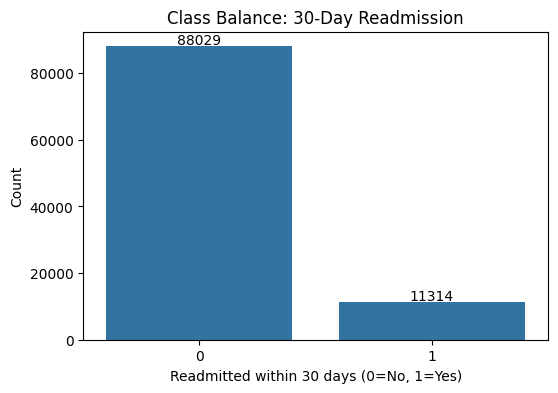

In [ ]:
# Class balance visualization
plt.figure(figsize=(6,4))
sns.countplot(x='readmitted_30d', data=df_clean)
plt.title('Class Balance: 30-Day Readmission')
plt.xlabel('Readmitted within 30 days (0=No, 1=Yes)')
plt.ylabel('Count')
for i, v in enumerate(df_clean['readmitted_30d'].value_counts().sort_index()):
    plt.text(i, v + 500, str(v), ha='center')
plt.show()

The target analysis shows that 11.4% of patients were readmitted within 30 days, while 88.6% were not, indicating a moderately imbalanced classification problem that will be considered during the modeling stage.

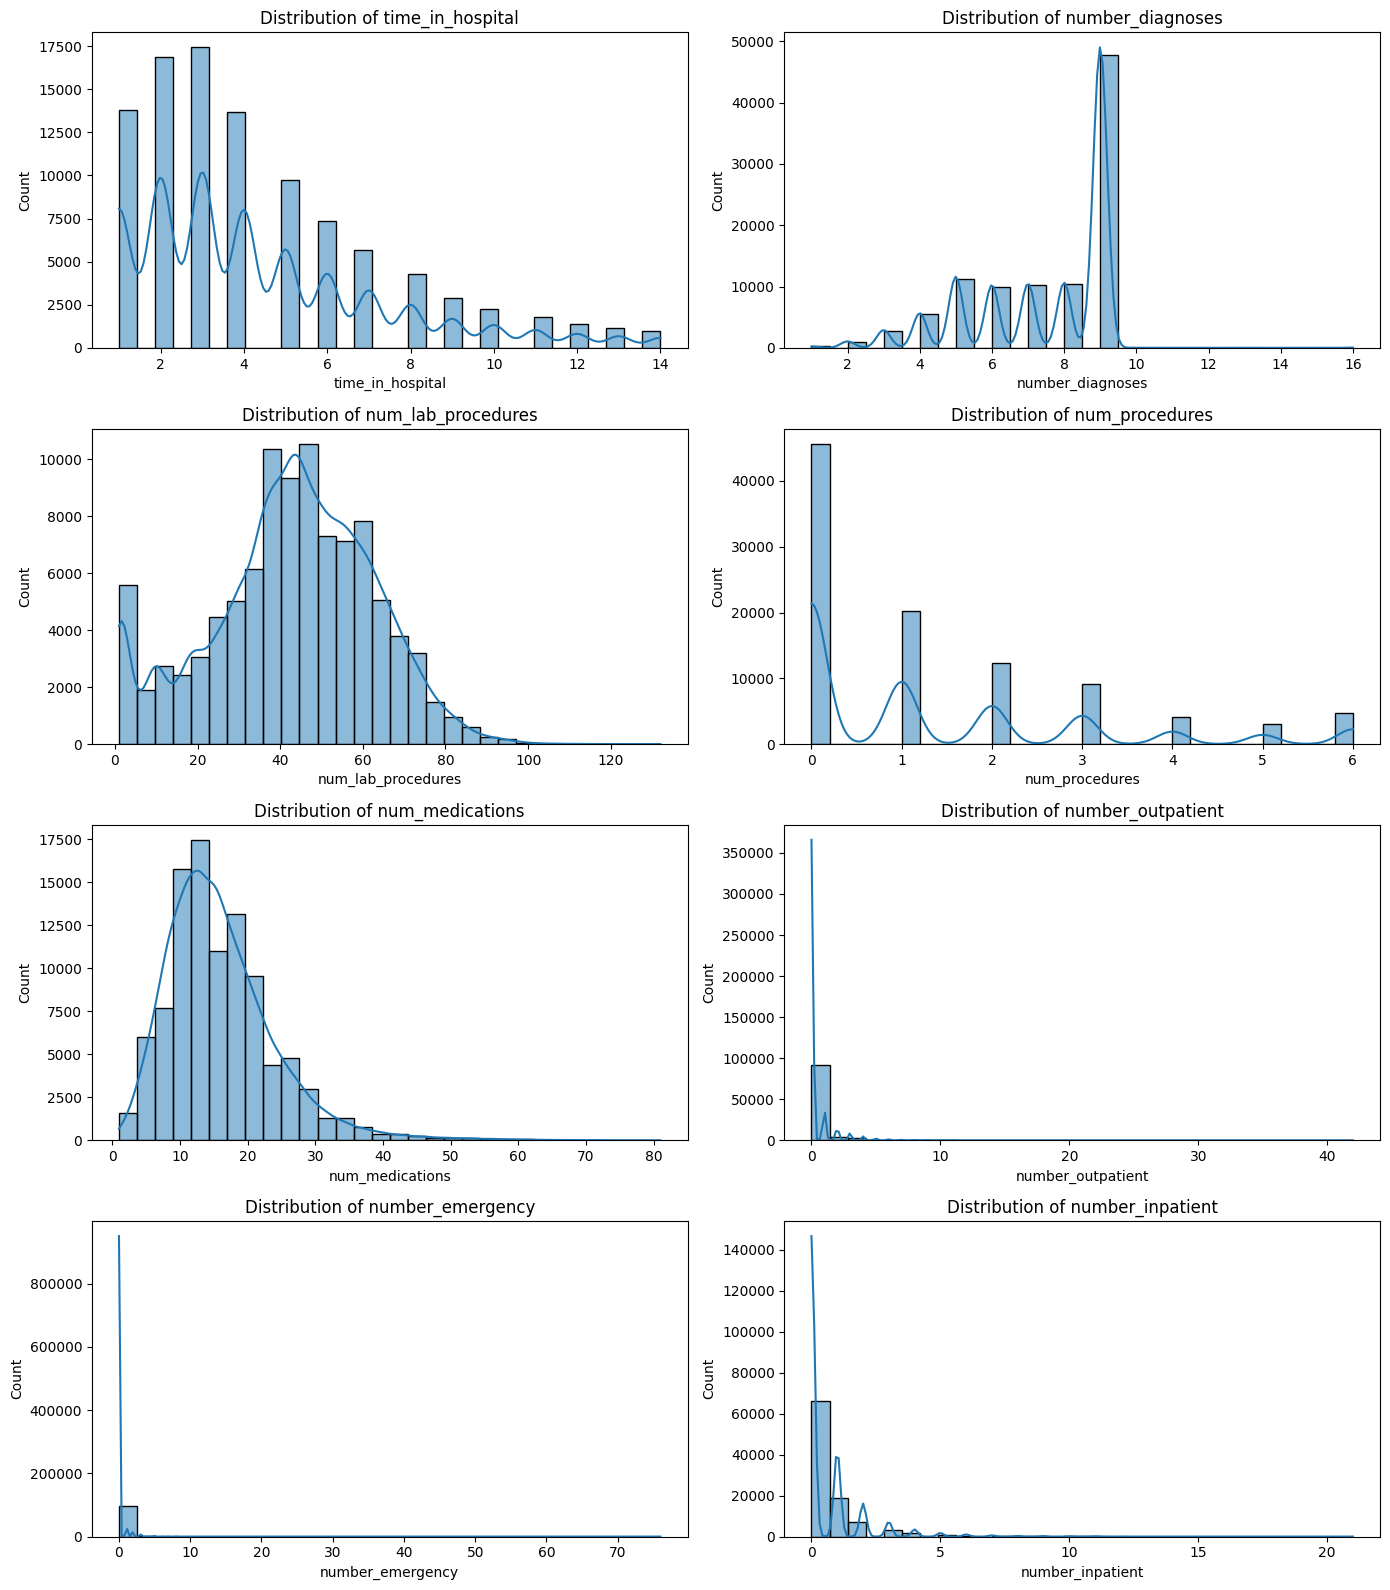

In [ ]:
# Univariate Analysis — Numeric Features
numeric_cols = ['time_in_hospital', 'number_diagnoses', 'num_lab_procedures',
                 'num_procedures', 'num_medications', 'number_outpatient',
                 'number_emergency', 'number_inpatient']

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df_clean[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

The numeric variables show clinically reasonable distributions. **Hospital stay duration** is moderately right-skewed, with most patients staying **2–4 days**. **Laboratory procedures** and **medication counts** show meaningful variation across patients and are likely to be informative predictors. **Procedure counts** are strongly right-skewed, with most encounters involving **no procedures**, which is expected in routine hospital admissions. The previous healthcare utilization variables (`number_outpatient`, `number_emergency`, and `number_inpatient`) are **highly right-skewed**, with the majority of patients having **zero prior visits** and a small subset showing repeated healthcare utilization. Overall, the distributions appear plausible for a hospital readmission dataset and do not indicate major data quality issues.


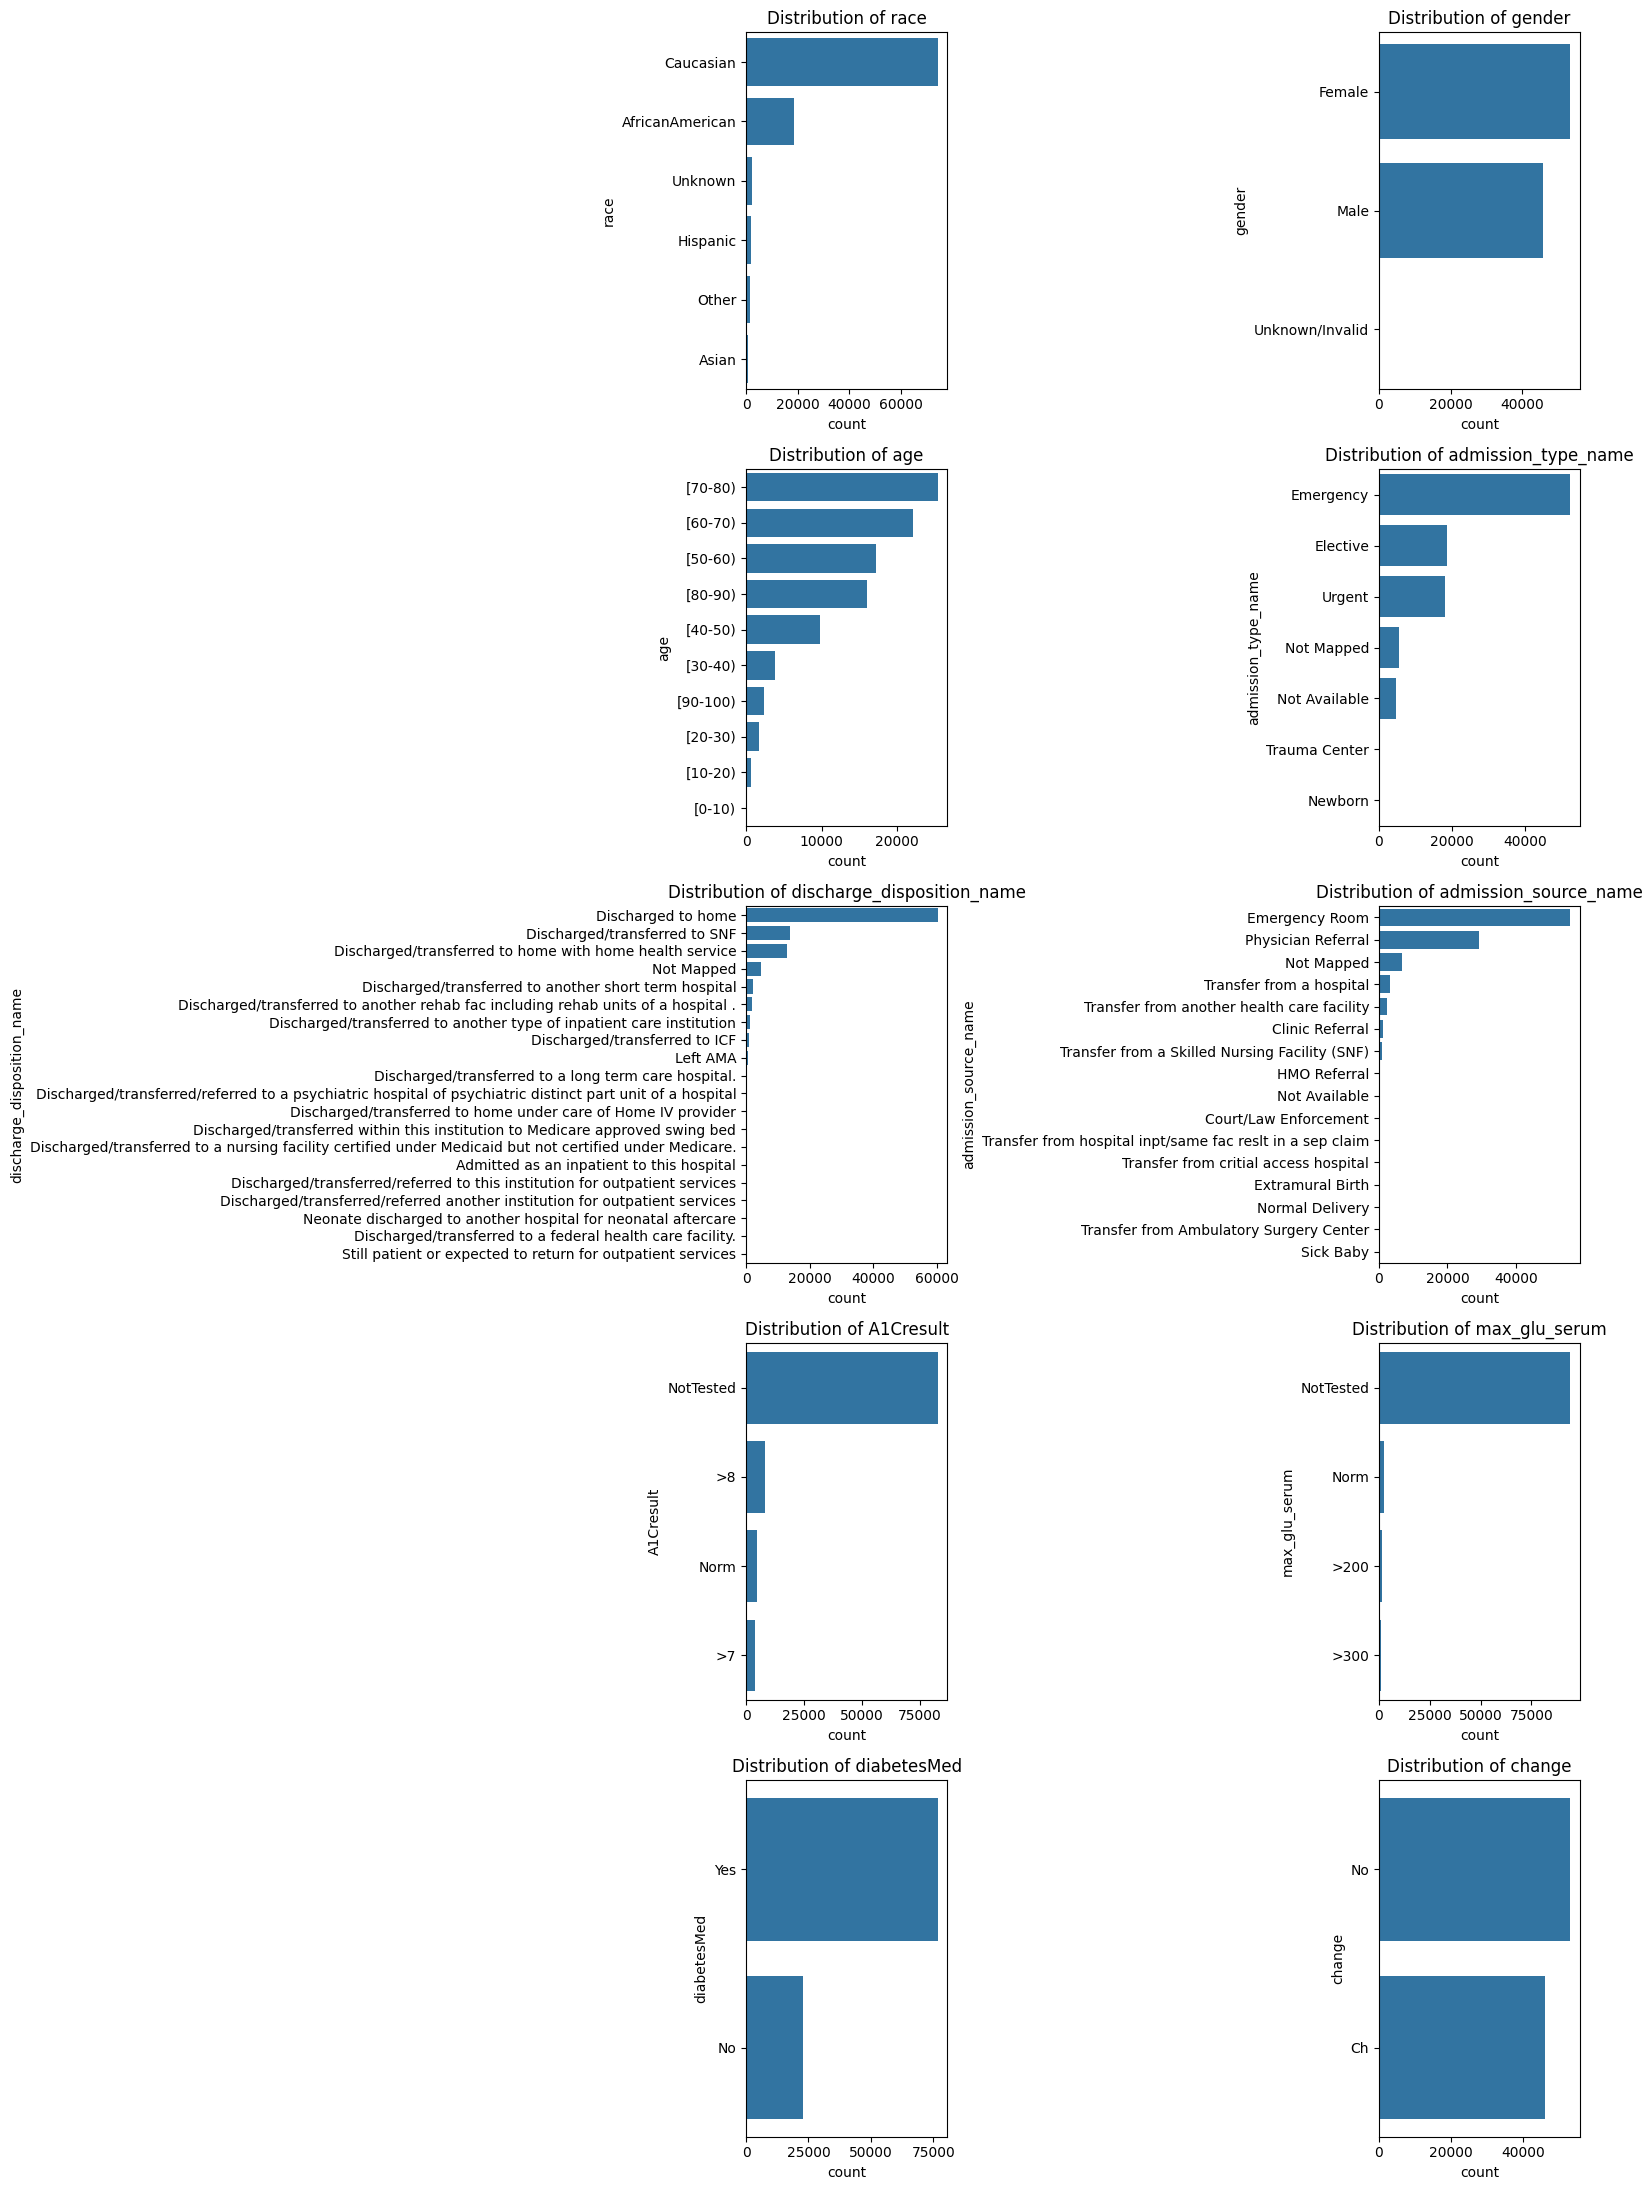

In [ ]:
# Univariate Analysis — Categorical Features
categorical_cols = ['race', 'gender', 'age', 'admission_type_name',
                     'discharge_disposition_name', 'admission_source_name',
                     'A1Cresult', 'max_glu_serum', 'diabetesMed', 'change']

fig, axes = plt.subplots(5, 2, figsize=(16, 22))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    order = df_clean[col].value_counts().index
    sns.countplot(y=col, data=df_clean, order=order, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

The categorical feature distributions show that the dataset is dominated by Caucasian patients, female patients, and the 70–80 age group, indicating that the hospitalized diabetic population is primarily composed of older adults.

Most encounters were emergency admissions originating from the emergency room, and the majority of patients were discharged to home. Several discharge disposition and admission source categories occur very infrequently, suggesting that rare-category grouping may be considered before encoding to reduce unnecessary dimensionality.

The laboratory-related variables A1Cresult and max_glu_serum are largely classified as NotTested, confirming that preserving NotTested as an explicit category was appropriate. The variables diabetesMed and change show meaningful variation across patients and are likely to provide useful predictive information for the readmission model.

In [ ]:
# Identifying Rare Categories
for col in ['discharge_disposition_name',
            'admission_source_name',
            'medical_specialty']:

    print(f'\n===== {col} =====')
    print(df_clean[col].value_counts().tail(10))


===== discharge_disposition_name =====
discharge_disposition_name
Discharged/transferred/referred to a psychiatric hospital of psychiatric distinct part unit of a hospital    139
Discharged/transferred to home under care of Home IV provider                                                108
Discharged/transferred within this institution to Medicare approved swing bed                                 63
Discharged/transferred to a nursing facility certified under Medicaid but not certified under Medicare.       48
Admitted as an inpatient to this hospital                                                                     21
Discharged/transferred/referred to this institution for outpatient services                                   14
Discharged/transferred/referred another institution for outpatient services                                   11
Neonate discharged to another hospital for neonatal aftercare                                                  6
Discharged/transferred to a f

In [ ]:
# Threshold evaluation (50 / 100 / 200)
for col in ['discharge_disposition_name', 'admission_source_name', 'medical_specialty']:
    counts = df_clean[col].value_counts()
    for threshold in [50, 100, 200]:
        rare_categories = counts[counts < threshold]
        print(f"{col} | threshold={threshold}: {len(rare_categories)} categories would be grouped into 'Other', covering {rare_categories.sum()} rows")
    print()

discharge_disposition_name | threshold=50: 7 categories would be grouped into 'Other', covering 108 rows
discharge_disposition_name | threshold=100: 8 categories would be grouped into 'Other', covering 171 rows
discharge_disposition_name | threshold=200: 10 categories would be grouped into 'Other', covering 418 rows

admission_source_name | threshold=50: 7 categories would be grouped into 'Other', covering 42 rows
admission_source_name | threshold=100: 7 categories would be grouped into 'Other', covering 42 rows
admission_source_name | threshold=200: 9 categories would be grouped into 'Other', covering 352 rows

medical_specialty | threshold=50: 38 categories would be grouped into 'Other', covering 483 rows
medical_specialty | threshold=100: 44 categories would be grouped into 'Other', covering 911 rows
medical_specialty | threshold=200: 51 categories would be grouped into 'Other', covering 1810 rows



In [ ]:
# Rare Category Grouping (discharge_disposition_name, admission_source_name, medical_specialty)
def group_rare_categories(series, threshold=100):
    counts = series.value_counts()
    rare = counts[counts < threshold].index
    return series.replace(rare, 'Other')

for col in ['discharge_disposition_name', 'admission_source_name', 'medical_specialty']:
    df_clean[col] = group_rare_categories(df_clean[col], threshold=100)

# Verify
for col in ['discharge_disposition_name', 'admission_source_name', 'medical_specialty']:
    print(f"\n===== {col} (after grouping) =====")
    print(f"Unique categories: {df_clean[col].nunique()}")
    print(df_clean[col].value_counts().tail(5))


===== discharge_disposition_name (after grouping) =====
Unique categories: 13
discharge_disposition_name
Left AMA                                                                                                     623
Discharged/transferred to a long term care hospital.                                                         412
Other                                                                                                        171
Discharged/transferred/referred to a psychiatric hospital of psychiatric distinct part unit of a hospital    139
Discharged/transferred to home under care of Home IV provider                                                108
Name: count, dtype: int64

===== admission_source_name (after grouping) =====
Unique categories: 10
admission_source_name
Clinic Referral                                   1081
Transfer from a Skilled Nursing Facility (SNF)     806
HMO Referral                                       185
Not Available                             

Rare-category grouping was applied to **discharge disposition**, **admission source**, and **medical specialty** using a **frequency threshold of 100 records**. Categories occurring in fewer than 100 encounters were consolidated into an **“Other”** category. This reduced the number of unique levels, prevented the creation of sparse one-hot encoded features, and preserved the major clinically meaningful categories for subsequent modeling.


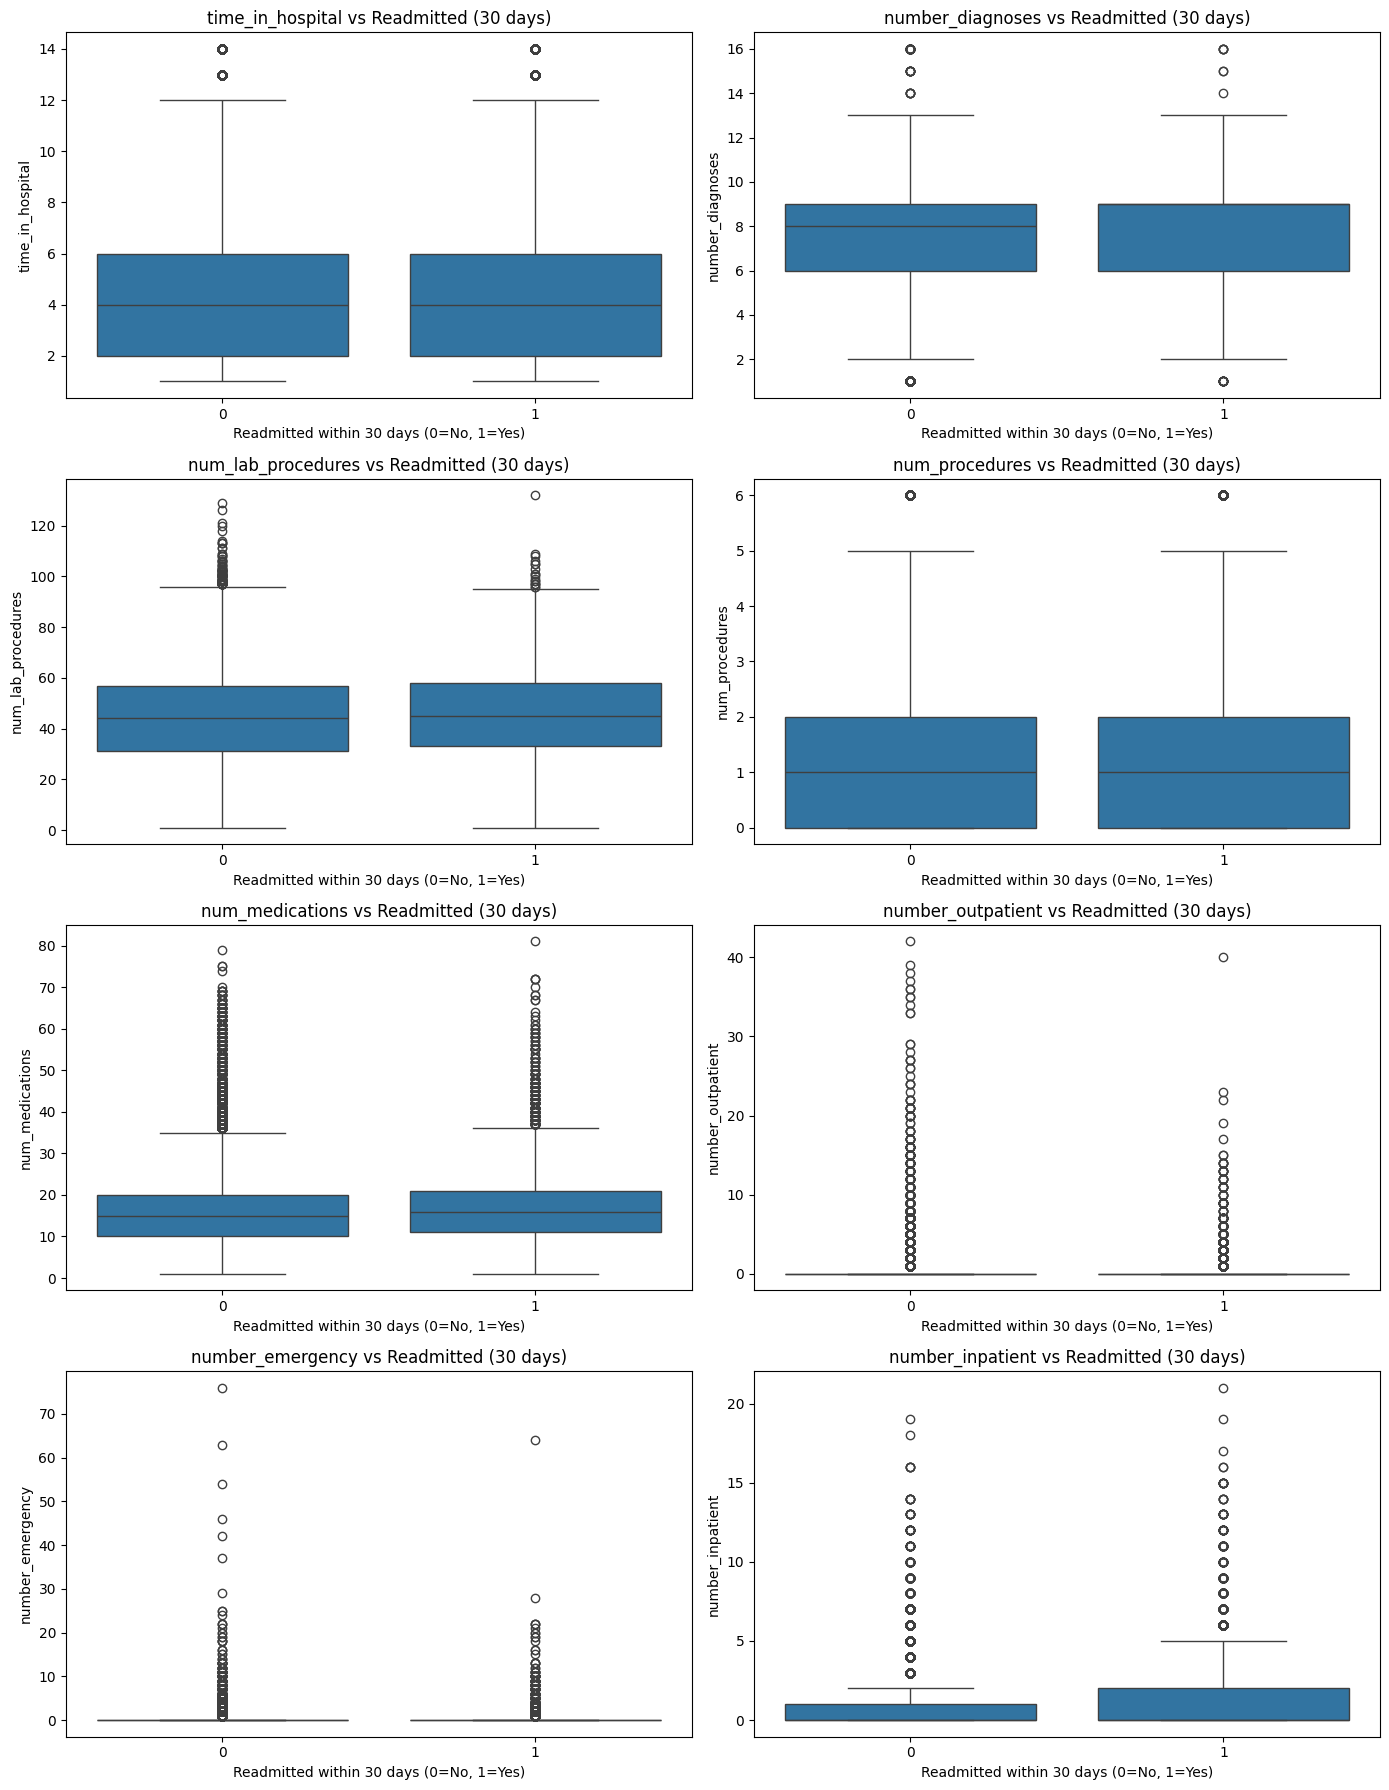

Mean values by readmission status:
                    Not Readmitted (0)  Readmitted <30d (1)  Difference
time_in_hospital              4.329437             4.767545    0.438108
number_diagnoses              7.364425             7.691798    0.327372
num_lab_procedures           42.737893            44.222114    1.484221
num_procedures                1.340854             1.282747   -0.058107
num_medications              15.859558            16.908874    1.049316
number_outpatient             0.360552             0.436892    0.076341
number_emergency              0.177975             0.357698    0.179723
number_inpatient              0.554874             1.222733    0.667859


In [ ]:
# Bivariate Analysis — Numeric Features vs. Target
numeric_cols = ['time_in_hospital', 'number_diagnoses', 'num_lab_procedures',
                 'num_procedures', 'num_medications', 'number_outpatient',
                 'number_emergency', 'number_inpatient']

# Boxplots: distribution of each numeric feature by readmission status
fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x='readmitted_30d', y=col, data=df_clean, ax=axes[i])
    axes[i].set_title(f'{col} vs Readmitted (30 days)')
    axes[i].set_xlabel('Readmitted within 30 days (0=No, 1=Yes)')

plt.tight_layout()
plt.show()

# Mean comparison table
print("Mean values by readmission status:")
mean_comparison = df_clean.groupby('readmitted_30d')[numeric_cols].mean().T
mean_comparison.columns = ['Not Readmitted (0)', 'Readmitted <30d (1)']
mean_comparison['Difference'] = mean_comparison['Readmitted <30d (1)'] - mean_comparison['Not Readmitted (0)']
print(mean_comparison)

The bivariate analysis shows that patients who were **readmitted within 30 days** generally had **slightly longer hospital stays, more recorded diagnoses, more laboratory procedures, and higher medication usage** compared with patients who were not readmitted.

The strongest difference appears in **number_inpatient**, where readmitted patients had **substantially higher previous inpatient utilization** (mean ≈ **1.22** vs **0.55**). **number_emergency** also shows a noticeable increase among readmitted patients.

In contrast, **num_procedures** shows very little difference between the two groups. Overall, previous healthcare utilization, medication burden, and hospital stay duration appear to be **more informative indicators of 30-day readmission risk** than the number of procedures performed during the admission.


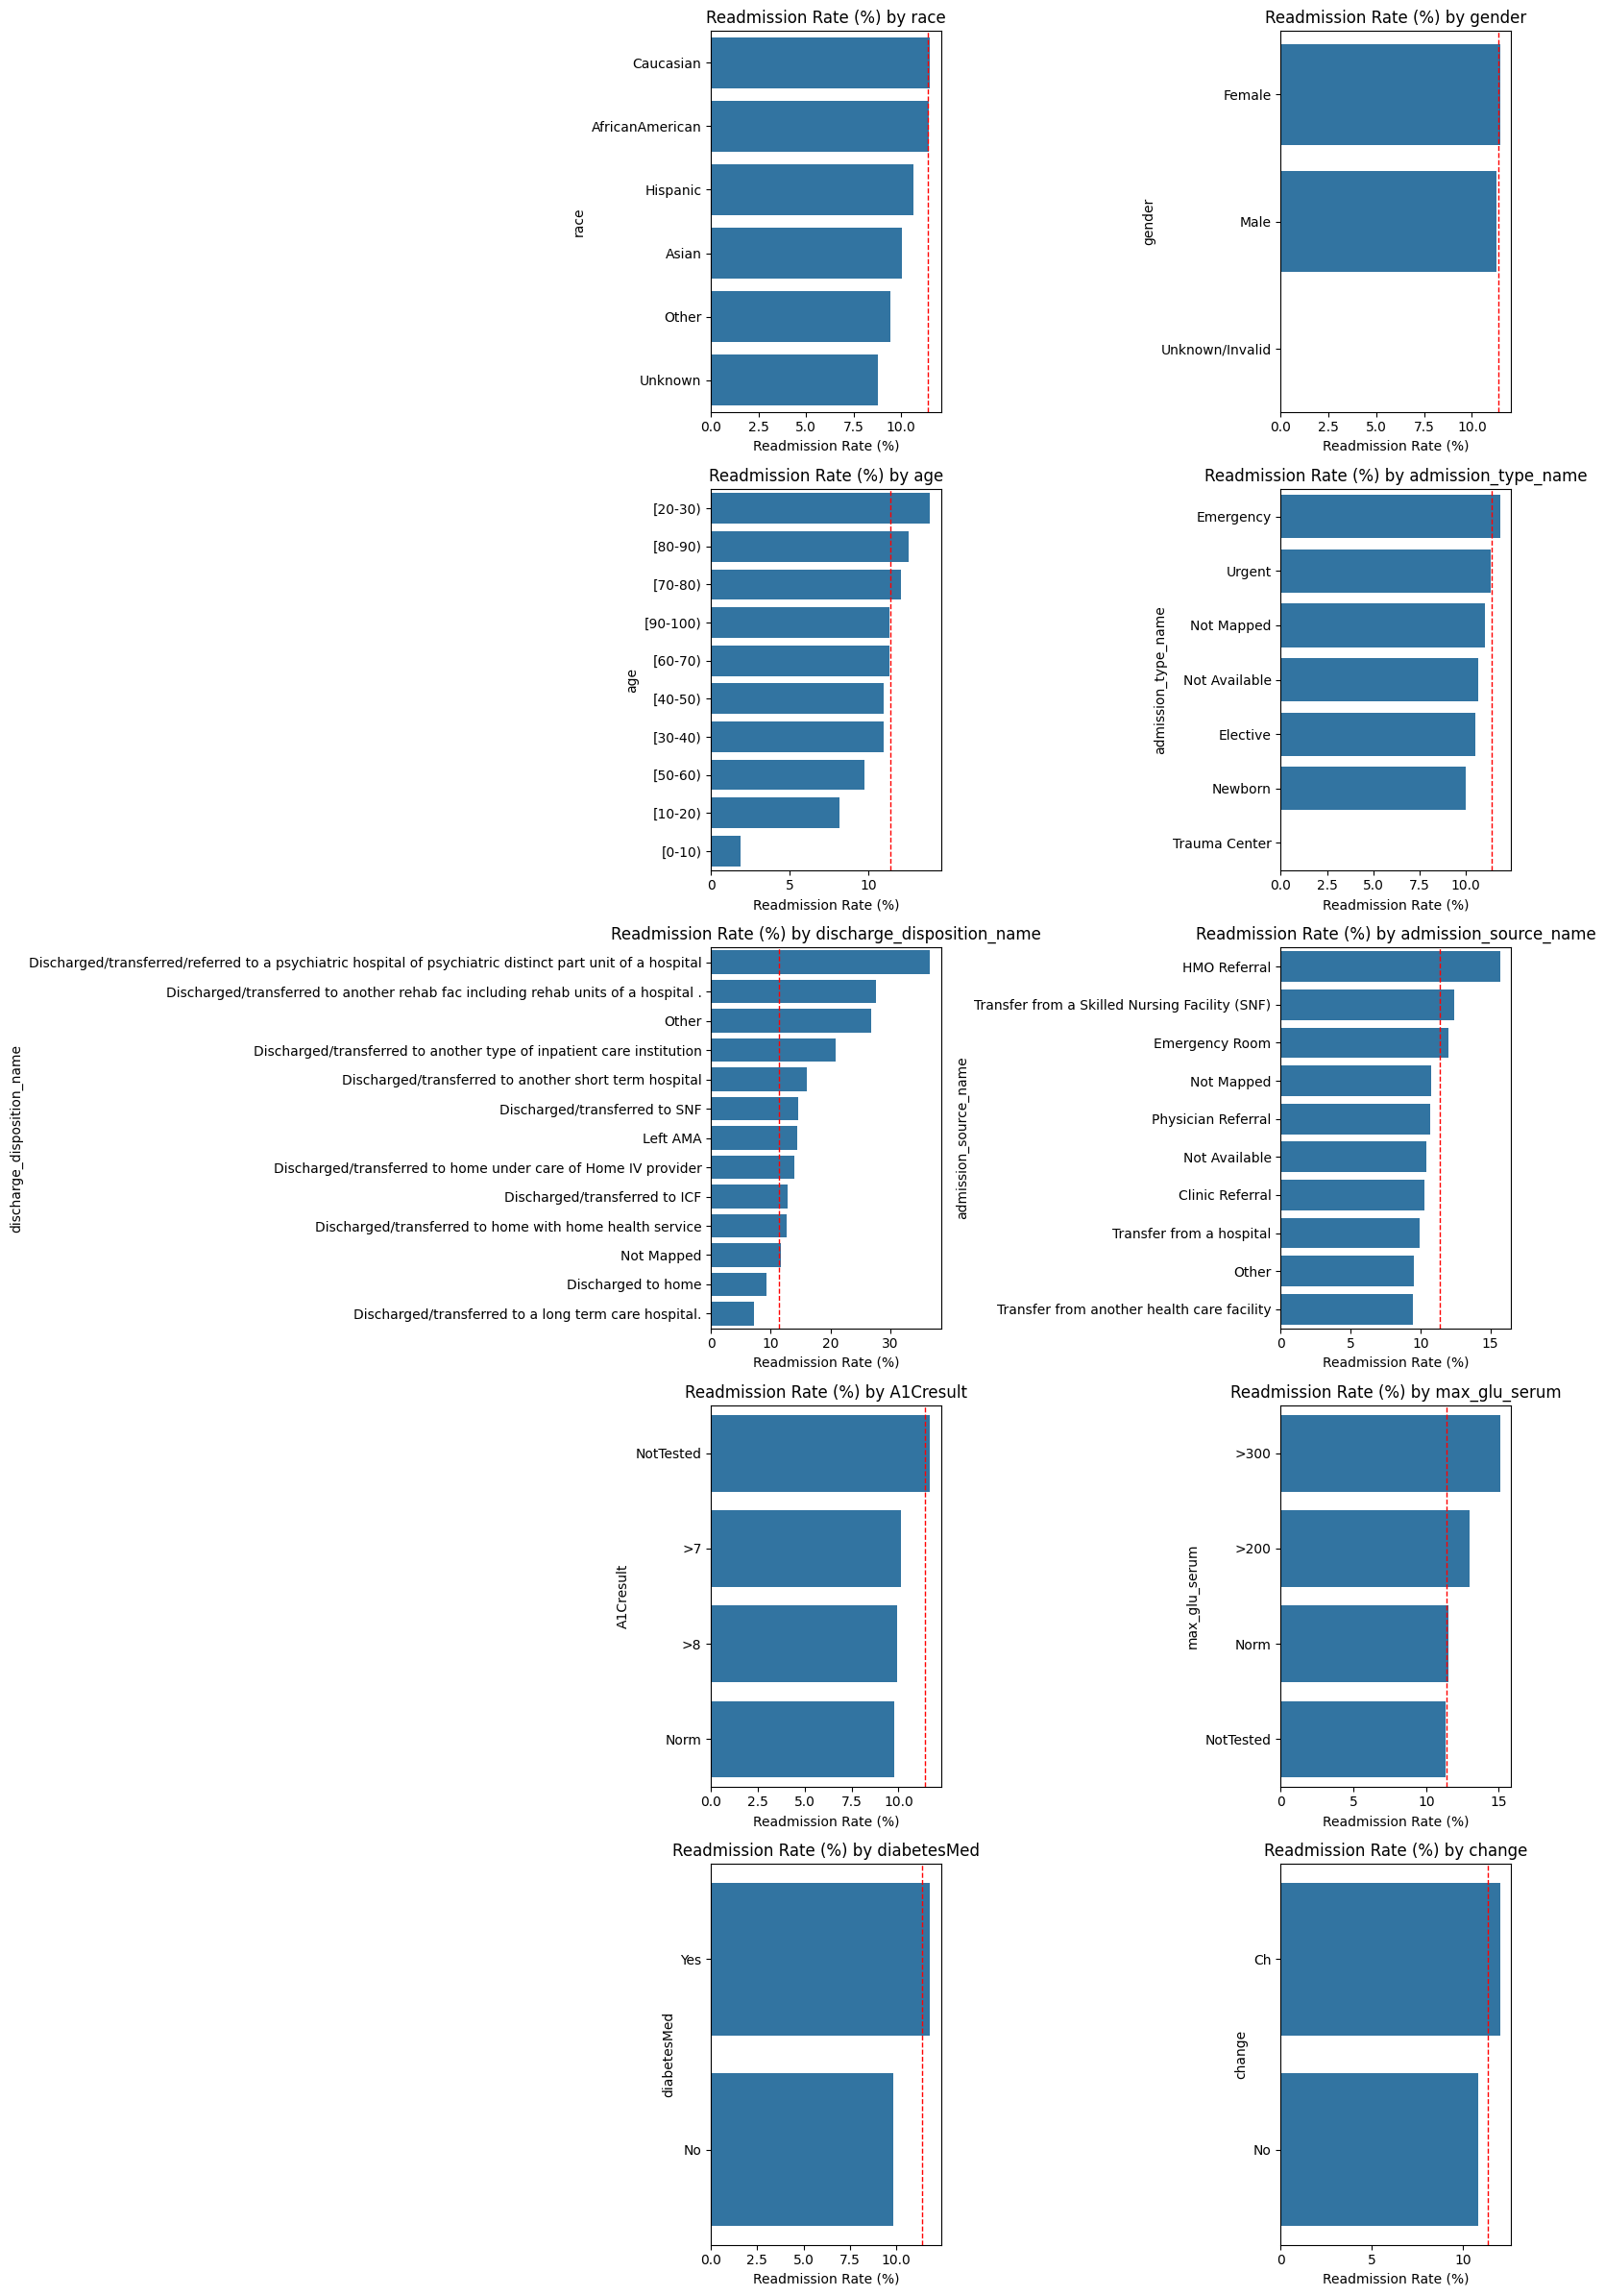

In [ ]:
# Bivariate Analysis — Categorical Features vs. Target
categorical_cols = ['race', 'gender', 'age', 'admission_type_name',
                     'discharge_disposition_name', 'admission_source_name',
                     'A1Cresult', 'max_glu_serum', 'diabetesMed', 'change']

fig, axes = plt.subplots(5, 2, figsize=(16, 24))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    # Calculate readmission RATE (%) per category, not just raw counts
    rate = df_clean.groupby(col)['readmitted_30d'].mean().sort_values(ascending=False) * 100
    sns.barplot(x=rate.values, y=rate.index, ax=axes[i])
    axes[i].set_title(f'Readmission Rate (%) by {col}')
    axes[i].set_xlabel('Readmission Rate (%)')
    axes[i].axvline(df_clean['readmitted_30d'].mean()*100, color='red', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

The categorical bivariate analysis shows that **emergency admissions, transfers from skilled nursing facilities, and several non-home discharge dispositions have higher-than-average 30-day readmission rates**. Older age groups also tend to show elevated readmission risk. Laboratory-related categories with **high serum glucose values** demonstrate increased readmission rates, while patients receiving **diabetes medication** or experiencing a **medication change during hospitalization** show slightly higher readmission rates than their respective comparison groups. Overall, **admission pathway, discharge disposition, prior care setting, and treatment-related factors appear to have stronger associations with 30-day readmission than demographic variables such as gender or race.**


## 4. Feature Engineering
### 4.1. ICD-9 Diagnosis Code Grouping

In [ ]:
def map_icd9_to_category(code):
    """
    Groups ICD-9 diagnosis codes into broader clinical categories,
    following the standard categorization used in Strack et al. (2014),
    the original research paper associated with this dataset.
    """
    if code == 'Unknown':
        return 'Unknown'
    code = str(code)

    if code.startswith('V'):
        return 'Supplemental (V-codes)'
    if code.startswith('E'):
        return 'External Causes (E-codes)'

    try:
        num = float(code)
    except ValueError:
        return 'Other'

    if 250 <= num < 251:
        return 'Diabetes'
    elif (390 <= num <= 459) or num == 785:
        return 'Circulatory'
    elif (460 <= num <= 519) or num == 786:
        return 'Respiratory'
    elif (520 <= num <= 579) or num == 787:
        return 'Digestive'
    elif 800 <= num <= 999:
        return 'Injury'
    elif 710 <= num <= 739:
        return 'Musculoskeletal'
    elif (580 <= num <= 629) or num == 788:
        return 'Genitourinary'
    elif 140 <= num <= 239:
        return 'Neoplasms'
    else:
        return 'Other'

# Apply to all three diagnosis columns
for col in ['diag_1', 'diag_2', 'diag_3']:
    df_clean[col + '_category'] = df_clean[col].apply(map_icd9_to_category)

# Verify
for col in ['diag_1_category', 'diag_2_category', 'diag_3_category']:
    print(f"\n===== {col} =====")
    print(df_clean[col].value_counts())

print("\nShape after adding diagnosis categories:", df_clean.shape)


===== diag_1_category =====
diag_1_category
Circulatory                  29681
Other                        16160
Respiratory                  13934
Digestive                     9333
Diabetes                      8661
Injury                        6853
Genitourinary                 5002
Musculoskeletal               4935
Neoplasms                     3131
Supplemental (V-codes)        1632
Unknown                         20
External Causes (E-codes)        1
Name: count, dtype: int64

===== diag_2_category =====
diag_2_category
Circulatory                  31158
Other                        23513
Diabetes                     12705
Respiratory                  10390
Genitourinary                 8147
Digestive                     4088
Injury                        2385
Neoplasms                     2326
Supplemental (V-codes)        1787
Musculoskeletal               1761
External Causes (E-codes)      727
Unknown                        356
Name: count, dtype: int64

===== diag_3_cate

In [ ]:
df_clean = df_clean.drop(columns=['diag_1', 'diag_2', 'diag_3'])
print("Shape after dropping raw diagnosis codes:", df_clean.shape)

Shape after dropping raw diagnosis codes: (99343, 34)


The ICD-9 diagnosis codes (diag_1, diag_2, and diag_3) were grouped into broader disease categories instead of using individual codes. This reduces the number of unique categories and makes the diagnosis information easier to interpret and use for machine learning.

The grouping helps the model capture overall disease patterns rather than treating every individual ICD-9 code as completely different. It also makes the results easier to explain through feature importance and SHAP.

### 4.2. Ordinal Encoding

In [ ]:
# Age: clear order from youngest to oldest
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
             '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']
age_map = {val: i for i, val in enumerate(age_order)}
df_clean['age_ordinal'] = df_clean['age'].map(age_map)

# A1Cresult: NotTested < Norm < >7 < >8 (blood sugar control severity)

a1c_map = {'NotTested': 0, 'Norm': 1, '>7': 2, '>8': 3}
df_clean['A1Cresult_ordinal'] = df_clean['A1Cresult'].map(a1c_map)

# max_glu_serum:
glu_map = {'NotTested': 0, 'Norm': 1, '>200': 2, '>300': 3}
df_clean['max_glu_serum_ordinal'] = df_clean['max_glu_serum'].map(glu_map)

# Medication columns: No < Steady < Down/Up (dosage change)
med_map = {'No': 0, 'Steady': 1, 'Down': 2, 'Up': 3}
med_cols = ['metformin', 'repaglinide', 'glimepiride', 'glipizide',
            'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin']
for col in med_cols:
    df_clean[col + '_ordinal'] = df_clean[col].map(med_map)

# Verify no missing values introduced
ordinal_cols = ['age_ordinal', 'A1Cresult_ordinal', 'max_glu_serum_ordinal'] + [c+'_ordinal' for c in med_cols]
print("Missing values check:")
print(df_clean[ordinal_cols].isnull().sum())
print("\nShape after ordinal encoding:", df_clean.shape)

Missing values check:
age_ordinal              0
A1Cresult_ordinal        0
max_glu_serum_ordinal    0
metformin_ordinal        0
repaglinide_ordinal      0
glimepiride_ordinal      0
glipizide_ordinal        0
glyburide_ordinal        0
pioglitazone_ordinal     0
rosiglitazone_ordinal    0
insulin_ordinal          0
dtype: int64

Shape after ordinal encoding: (99343, 45)


### 4.3. One-Hot Encoding

In [ ]:
onehot_cols = ['race', 'gender', 'admission_type_name', 'discharge_disposition_name',
               'admission_source_name', 'medical_specialty', 'diag_1_category',
               'diag_2_category', 'diag_3_category', 'diabetesMed', 'change']

df_encoded = pd.get_dummies(df_clean, columns=onehot_cols, drop_first=True)

print("Shape after one-hot encoding:", df_encoded.shape)
print("\nSample of new columns:")
print([c for c in df_encoded.columns if 'race_' in c or 'gender_' in c])

Shape after one-hot encoding: (99343, 132)

Sample of new columns:
['race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Other', 'race_Unknown', 'gender_Male', 'gender_Unknown/Invalid']


In [ ]:
# Drop original text columns now that ordinal-encoded versions exist
original_ordinal_source_cols = ['age', 'A1Cresult', 'max_glu_serum',
                                 'metformin', 'repaglinide', 'glimepiride',
                                 'glipizide', 'glyburide', 'pioglitazone',
                                 'rosiglitazone', 'insulin']

df_encoded = df_encoded.drop(columns=original_ordinal_source_cols)

print("Shape after dropping original text columns:", df_encoded.shape)
print("\nRemaining non-numeric columns (should be minimal):")
print(df_encoded.select_dtypes(include='object').columns.tolist())

Shape after dropping original text columns: (99343, 121)

Remaining non-numeric columns (should be minimal):
['readmitted']


In [ ]:
# Convert boolean one-hot columns to integers
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

# Confirm identifier columns are NOT used as features
print("Bool columns converted:", len(bool_cols))
print("\nConfirming identifier columns still present (to be excluded before modeling):")
print(['encounter_id' in df_encoded.columns, 'patient_nbr' in df_encoded.columns])

print("\nFinal shape:", df_encoded.shape)
print(df_encoded.dtypes.value_counts())

Bool columns converted: 98

Confirming identifier columns still present (to be excluded before modeling):
[True, True]

Final shape: (99343, 121)
int64     120
object      1
Name: count, dtype: int64


The original text-based categorical columns were removed after creating their encoded versions, since keeping both would be redundant. Boolean one-hot encoded columns were converted to 0 and 1 so that all features were in a numerical format suitable for machine learning models.

In [ ]:
df_encoded

,encounter_id,patient_nbr,time_in_hospital,number_diagnoses,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,...,diag_3_category_Genitourinary,diag_3_category_Injury,diag_3_category_Musculoskeletal,diag_3_category_Neoplasms,diag_3_category_Other,diag_3_category_Respiratory,diag_3_category_Supplemental (V-codes),diag_3_category_Unknown,diabetesMed_Yes,change_No
0,2278392,8222157,1,1,41,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,1
1,149190,55629189,3,9,59,0,18,0,0,0,...,0,0,0,0,1,0,0,0,1,0
2,64410,86047875,2,6,11,5,13,2,0,1,...,0,0,0,0,0,0,1,0,1,1
3,500364,82442376,2,7,44,1,16,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,16680,42519267,1,5,51,0,8,0,0,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99338,443847548,100162476,3,9,51,0,16,0,0,0,...,0,0,0,0,0,0,0,0,1,0
99339,443847782,74694222,5,9,33,3,18,0,0,1,...,0,0,0,0,0,0,0,0,1,1
99340,443854148,41088789,1,13,53,0,9,1,0,0,...,0,0,0,0,1,0,0,0,1,0
99341,443857166,31693671,10,9,45,2,21,0,0,1,...,0,1,0,0,0,0,0,0,1,0


In [ ]:
print(df_encoded.select_dtypes(include='object').columns.tolist())

['readmitted']


In [ ]:
# Dropping redundant target column (readmitted)
df_encoded = df_encoded.drop(columns=['readmitted'])

print("Final shape:", df_encoded.shape)
print("Remaining object columns:", df_encoded.select_dtypes(include='object').columns.tolist())
print(df_encoded.dtypes.value_counts())

Final shape: (99343, 120)
Remaining object columns: []
int64    120
Name: count, dtype: int64


## 5. Model Preparation

### 5.1. Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split
# Exclude the identifiers and target from features
exclude_cols = ['encounter_id', 'patient_nbr', 'readmitted_30d']
X = df_encoded.drop(columns=exclude_cols)
y = df_encoded['readmitted_30d']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("x_test shape:", X_test.shape)
print("\nTrain set class balance (%):")
print(y_train.value_counts(normalize=True)*100)
print("\nTest set class balance (%):")
print(y_test.value_counts(normalize=True)*100)


X_train shape: (79474, 117)
x_test shape: (19869, 117)

Train set class balance (%):
readmitted_30d
0    88.61137
1    11.38863
Name: proportion, dtype: float64

Test set class balance (%):
readmitted_30d
0    88.610398
1    11.389602
Name: proportion, dtype: float64


### 5.2. Handling Class Imbalance (SMOTE)

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_smote.value_counts())

print("\nX_train_smote shape:", X_train_smote.shape)

Before SMOTE: readmitted_30d
0    70423
1     9051
Name: count, dtype: int64
After SMOTE: readmitted_30d
0    70423
1    70423
Name: count, dtype: int64

X_train_smote shape: (140846, 117)


## 6. Model Training and Evaluation

### 6.1. Baseline Model Training
- Trained Logistic Regression, Random Forest, and XGBoost on
  SMOTE-balanced training data
- Logistic Regression used scaled features (StandardScaler);
  tree-based models used original (unscaled) features

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

#---------------------------------------------------
# Scaling - required for Logistic Regression only
#---------------------------------------------------
scaler = StandardScaler()
X_train_smote_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

#---------------------------------------------------
# Train Logistic Regression (on scaled data)
#---------------------------------------------------
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_smote_scaled, y_train_smote)
print("Logistic Regression trained.")

#----------------------------------------------------
# Train Random Forest (on Original unscaled data)
#----------------------------------------------------
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_smote, y_train_smote)
print("Random Forest trained.")

#-----------------------------------------------------
# Train XGBoost (on original unscaled data)
#-----------------------------------------------------
xgb = XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1)
xgb.fit(X_train_smote, y_train_smote)
print("XGBoost trained.")

print("\nAll three models trained successfully.")

Logistic Regression trained.
Random Forest trained.
XGBoost trained.

All three models trained successfully.


### 6.2. Baseline Evaluation (Default Threshold = 0.5)

===== Logistic Regression =====
              precision    recall  f1-score   support

           0       0.89      0.91      0.90     17606
           1       0.14      0.11      0.13      2263

    accuracy                           0.82     19869
   macro avg       0.52      0.51      0.51     19869
weighted avg       0.80      0.82      0.81     19869

ROC-AUC: 0.5449089911249775
===== Random Forest =====
              precision    recall  f1-score   support

           0       0.89      0.97      0.93     17606
           1       0.13      0.03      0.05      2263

    accuracy                           0.87     19869
   macro avg       0.51      0.50      0.49     19869
weighted avg       0.80      0.87      0.83     19869

ROC-AUC: 0.5845310237255416
===== XGBoost =====
              precision    recall  f1-score   support

           0       0.89      0.93      0.91     17606
           1       0.16      0.11      0.13      2263

    accuracy                           0.84     

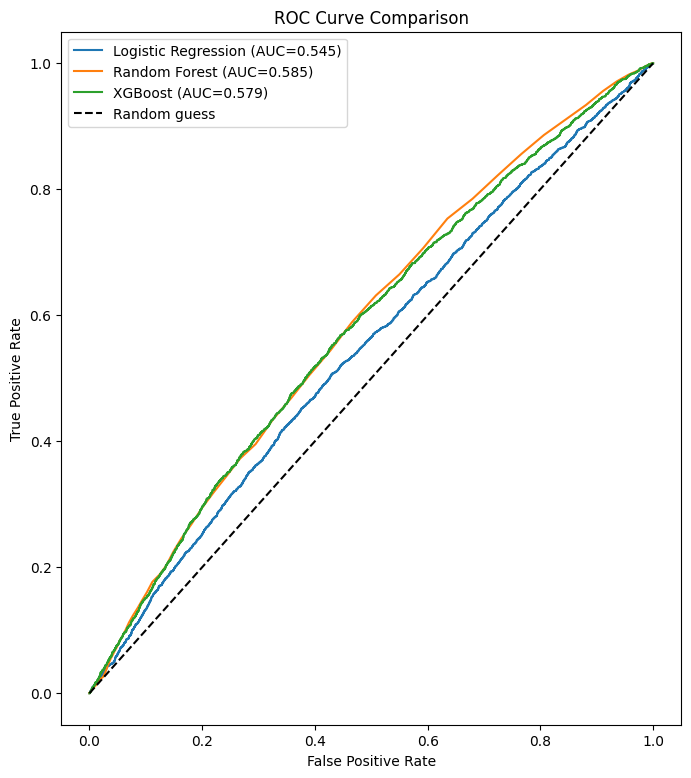

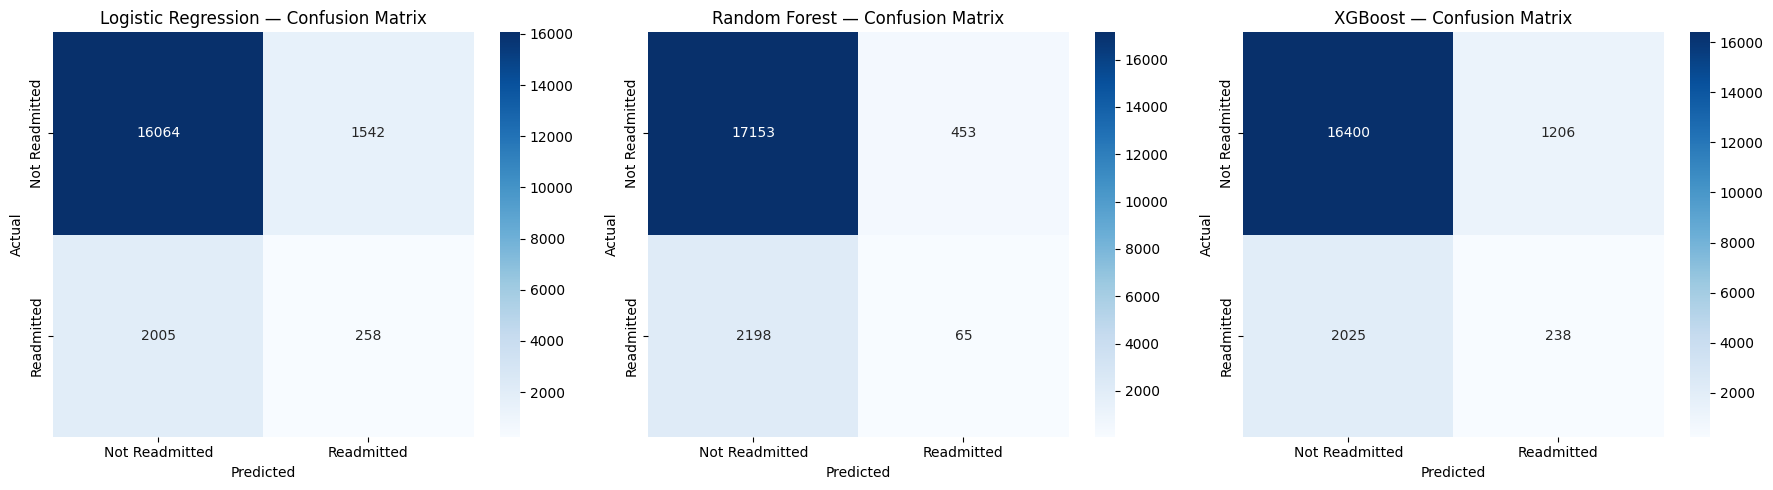

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve

# --------------------------------------------------
# Predictions
# --------------------------------------------------
log_reg_pred = log_reg.predict(X_test_scaled)
log_reg_proba = log_reg.predict_proba(X_test_scaled)[:,1]

rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:,1]

xgb_pred = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)[:,1]

# -------------------------------------------------
# Classification report (precision, recall, F1 per class)
# -------------------------------------------------
print("===== Logistic Regression =====")
print(classification_report(y_test, log_reg_pred))
print("ROC-AUC:", roc_auc_score(y_test, log_reg_proba))

print("===== Random Forest =====")
print(classification_report(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_proba))

print("===== XGBoost =====")
print(classification_report(y_test, xgb_pred))
print("ROC-AUC:", roc_auc_score(y_test, xgb_proba))

# ------------------------------------------------
# ROC Curve
# ------------------------------------------------
plt.figure(figsize=(8,9))
for name, proba in [('Logistic Regression', log_reg_proba), ('Random Forest', rf_proba), ('XGBoost', xgb_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1],[0,1],'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

# ------------------------------------------------
# Confusion Matrices
# ------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_preds = [
    ('Logistic Regression', log_reg_pred),
    ('Random Forest', rf_pred),
    ('XGBoost', xgb_pred)
]

for i, (name, pred) in enumerate(models_preds):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Not Readmitted', 'Readmitted'],
                yticklabels=['Not Readmitted', 'Readmitted'])
    axes[i].set_title(f'{name} — Confusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()


- Evaluated all three models using classification reports,
  ROC-AUC, and confusion matrices
- Finding: very low recall for the minority (readmitted) class
  across all models — default threshold poorly suited to
  imbalanced test data

Random Forest was selected for further optimization because it achieved the highest ROC-AUC (0.585) among the evaluated models. Since ROC-AUC is threshold-independent and reflects the model’s overall discriminative ability across all possible decision thresholds, it was used as the primary basis for model selection. Random Forest was therefore carried forward for leakage-free hyperparameter tuning and subsequent threshold optimization to improve minority-class detection while maintaining acceptable overall accuracy.

## 7. Hyperparameter Tuning

In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# Build a pipeline where SMOTE is applied fresh within each CV fold
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42, n_jobs=-1))
])

param_dist = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [10, 15, 20, None],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
}

rf_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=15,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

print("Best parameters:", rf_search.best_params_)
print("Best ROC-AUC (properly cross-validated, no leakage):", rf_search.best_score_)

rf_tuned = rf_search.best_estimator_

Fitting 3 folds for each of 15 candidates, totalling 45 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters: {'rf__n_estimators': 300, 'rf__min_samples_split': 2, 'rf__min_samples_leaf': 1, 'rf__max_depth': None}
Best ROC-AUC (properly cross-validated, no leakage): 0.5891766050376497


In [ ]:

# =========================================================
# Evaluate tuned Random Forest at default threshold = 0.5
# =========================================================

# Predicted probabilities for the positive class (readmitted)
rf_tuned_proba = rf_tuned.predict_proba(X_test)[:, 1]

# Default classification threshold = 0.5
rf_tuned_pred = (rf_tuned_proba >= 0.50).astype(int)

# ---------------------------------------------------------
# ROC-AUC
# ---------------------------------------------------------

print("===== Tuned Random Forest (Default Threshold = 0.5) =====")
print("ROC-AUC:", round(roc_auc_score(y_test, rf_tuned_proba), 3))

# ---------------------------------------------------------
# Classification report
# ---------------------------------------------------------

print("\nClassification Report:")
print(classification_report(y_test, rf_tuned_pred))

# ---------------------------------------------------------
# Confusion matrix
# ---------------------------------------------------------

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_tuned_pred))

===== Tuned Random Forest (Default Threshold = 0.5) =====
ROC-AUC: 0.591

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.97      0.93     17606
           1       0.13      0.03      0.05      2263

    accuracy                           0.87     19869
   macro avg       0.51      0.50      0.49     19869
weighted avg       0.80      0.87      0.83     19869


Confusion Matrix:
[[17163   443]
 [ 2195    68]]


Random Forest was tuned using RandomizedSearchCV with an imblearn Pipeline containing SMOTE and RandomForestClassifier. SMOTE was applied inside each cross-validation fold to prevent data leakage. An earlier naive approach that applied SMOTE before cross-validation produced an inflated ROC-AUC (~0.955), whereas the corrected leakage-free pipeline achieved a cross-validated ROC-AUC of 0.589, consistent with the independent test ROC-AUC of 0.591.

### 7.1. Threshold Selection (Cross-Validated)

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# Generate out-of-fold probabilities from TRAINING data
# ---------------------------------------------------------

train_cv_proba = cross_val_predict(
    rf_tuned,
    X_train,
    y_train,
    cv=3,
    method='predict_proba',
    n_jobs=-1
)[:, 1]

# ---------------------------------------------------------
# Search thresholds on TRAINING-CV predictions
# ---------------------------------------------------------

threshold_results = []

for threshold in np.arange(0.05, 0.51, 0.01):

    pred = (train_cv_proba >= threshold).astype(int)

    threshold_results.append({
        'threshold': round(threshold, 2),
        'accuracy': accuracy_score(y_train, pred),
        'precision': precision_score(y_train, pred, zero_division=0),
        'recall': recall_score(y_train, pred, zero_division=0),
        'f1': f1_score(y_train, pred, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)

# Keep only thresholds with >= 80% accuracy
valid_thresholds = threshold_df[
    threshold_df['accuracy'] >= 0.80
].sort_values(['recall', 'f1'], ascending=False)

print(valid_thresholds.head(10))

    threshold  accuracy  precision    recall        f1
27       0.32  0.800337   0.156574  0.171694  0.163786
28       0.33  0.805534   0.155477  0.159651  0.157536
29       0.34  0.813423   0.156008  0.144735  0.150160
30       0.35  0.822193   0.154422  0.125401  0.138406
31       0.36  0.828409   0.154148  0.112916  0.130349
32       0.37  0.833468   0.153183  0.102088  0.122522
33       0.38  0.837909   0.148080  0.089051  0.111218
34       0.39  0.842477   0.148846  0.081206  0.105083
35       0.40  0.846252   0.148156  0.073694  0.098428
36       0.41  0.849460   0.147593  0.067396  0.092536


Because the dataset was imbalanced, the default threshold of 0.5 produced very low recall for the readmission class. cross_val_predict was used to generate out-of-fold probabilities on the training data only, and thresholds from 0.05 to 0.50 were evaluated. The threshold that maximized recall while maintaining accuracy ≥ 80% was selected, ensuring that the test set was not used during threshold selection.

### 7.2. Final Threshold and Test Evaluation

In [ ]:
# ---------------------------------------------------------
# Final test evaluation using the threshold selected
# from training CV
# ---------------------------------------------------------

best_threshold = valid_thresholds.iloc[0]['threshold']
print("Selected threshold:", best_threshold)
rf_final_proba = rf_tuned.predict_proba(X_test)[:, 1]

rf_final_pred = (
    rf_final_proba >= best_threshold
).astype(int)

print("===== FINAL TUNED RANDOM FOREST =====")
print("Threshold:", best_threshold)

print("\nClassification Report:")
print(classification_report(y_test, rf_final_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_final_pred))

print("\nROC-AUC:",
      round(roc_auc_score(y_test, rf_final_proba), 3))

Selected threshold: 0.32
===== FINAL TUNED RANDOM FOREST =====
Threshold: 0.32

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.88      0.89     17606
           1       0.17      0.19      0.18      2263

    accuracy                           0.80     19869
   macro avg       0.53      0.54      0.53     19869
weighted avg       0.81      0.80      0.81     19869


Confusion Matrix:
[[15448  2158]
 [ 1825   438]]

ROC-AUC: 0.591


The selected threshold was 0.32. It was applied once to the untouched test set, producing the final evaluation. Compared with the default threshold of 0.5, the optimized threshold improved minority-class recall while maintaining the required 80% accuracy constraint.

In [ ]:
from sklearn.dummy import DummyClassifier

# ---------------------------------------------------------
# Baseline comparison — Dummy Classifier
# Establishes a minimum baseline: is the model better than
# random / naive guessing?
# ---------------------------------------------------------
dummy = DummyClassifier(strategy='stratified', random_state=42)
dummy.fit(X_train, y_train)
dummy_proba = dummy.predict_proba(X_test)[:, 1]

print("===== Baseline Check =====")
print("Dummy Classifier ROC-AUC:", round(roc_auc_score(y_test, dummy_proba), 3))
print("Tuned Random Forest ROC-AUC:", round(roc_auc_score(y_test, rf_tuned_proba), 3))

# ---------------------------------------------------------
# Generalization / Overfitting check
# A large train-test gap would indicate overfitting.
# ---------------------------------------------------------
train_proba = rf_tuned.predict_proba(X_train)[:, 1]
train_auc = roc_auc_score(y_train, train_proba)
test_auc = roc_auc_score(y_test, rf_tuned_proba)

print("\n===== Generalization Check =====")
print("Train ROC-AUC:", round(train_auc, 3))
print("Test ROC-AUC:", round(test_auc, 3))
print("ROC-AUC Gap:", round(train_auc - test_auc, 3))

# ---------------------------------------------------------
# Investigation: can constraining tree depth reduce the gap
# without hurting test performance?
# ---------------------------------------------------------
rf_constrained_d10 = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=300, max_depth=10,
                                    min_samples_leaf=5, random_state=42, n_jobs=-1))
])
rf_constrained_d10.fit(X_train, y_train)
d10_train_auc = roc_auc_score(y_train, rf_constrained_d10.predict_proba(X_train)[:,1])
d10_test_auc = roc_auc_score(y_test, rf_constrained_d10.predict_proba(X_test)[:,1])

rf_constrained_d20 = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=300, max_depth=20,
                                    min_samples_leaf=2, random_state=42, n_jobs=-1))
])
rf_constrained_d20.fit(X_train, y_train)
d20_train_auc = roc_auc_score(y_train, rf_constrained_d20.predict_proba(X_train)[:,1])
d20_test_auc = roc_auc_score(y_test, rf_constrained_d20.predict_proba(X_test)[:,1])

comparison = pd.DataFrame({
    'Model': ['Original Tuned RF', 'Depth=10', 'Depth=20'],
    'Train ROC-AUC': [train_auc, d10_train_auc, d20_train_auc],
    'Test ROC-AUC': [test_auc, d10_test_auc, d20_test_auc],
})
comparison['Gap'] = comparison['Train ROC-AUC'] - comparison['Test ROC-AUC']
print("\n===== Overfitting Investigation =====")
print(comparison)

===== Baseline Check =====
Dummy Classifier ROC-AUC: 0.496
Tuned Random Forest ROC-AUC: 0.591

===== Generalization Check =====
Train ROC-AUC: 1.0
Test ROC-AUC: 0.591
ROC-AUC Gap: 0.409

===== Overfitting Investigation =====
               Model  Train ROC-AUC  Test ROC-AUC       Gap
0  Original Tuned RF       0.999996      0.591471  0.408525
1           Depth=10       0.590119      0.542461  0.047658
2           Depth=20       0.880007      0.568455  0.311551


* To check how well the tuned Random Forest generalizes to unseen data, it was compared with a Dummy Classifier baseline, which achieved a ROC-AUC of 0.496. The tuned Random Forest achieved a higher test ROC-AUC of 0.591, showing that the model is learning some useful predictive patterns rather than simply guessing.

* However, the model achieved a perfect ROC-AUC of 1.00 on the training data compared with 0.591 on the test data. This large gap suggests that the model is fitting the training data very closely and may be overfitting.

To investigate this further, two versions of the Random Forest with restricted tree depths were tested:

* Limiting the tree depth clearly reduced the difference between training and test performance. However, it also caused the test AUC to decrease from 0.591 to 0.568 and then to 0.542. This suggests that while the original model has some overfitting, its additional complexity is also helping it capture useful patterns in the data. Therefore, the original tuned Random Forest was retained as the final model because it achieved the best test-set performance.

## 8. Model + artifact saving (joblib)

In [ ]:
import joblib
import os

save_path = '/content/drive/My Drive/Dataset/Hospital readmission/'
os.makedirs(save_path, exist_ok=True)

# Save the final tuned Random Forest model
joblib.dump(rf_tuned, save_path + 'rf_tuned_model.pkl')

# Save exact feature column order
feature_columns = X_train.columns.tolist()
joblib.dump(feature_columns, save_path + 'feature_columns.pkl')

# Save final selected threshold (0.32)
joblib.dump(best_threshold, save_path + 'final_threshold.pkl')

# Save scaler (optional for RF)
joblib.dump(scaler, save_path + 'scaler.pkl')

# Save default patient profile (needed for Streamlit app)
default_row = X_train.median()
joblib.dump(default_row, save_path + 'default_row.pkl')

print('Model and artifacts saved to Google Drive:')
print(save_path)

# Verification
rf_loaded = joblib.load(save_path + 'rf_tuned_model.pkl')
saved_threshold = joblib.load(save_path + 'final_threshold.pkl')
saved_default_row = joblib.load(save_path + 'default_row.pkl')

print('\nVerification — reloaded object type:', type(rf_loaded))
print('Pipeline steps:', rf_loaded.named_steps.keys())
print('Saved threshold:', saved_threshold)
print('default_row length:', len(saved_default_row))

Model and artifacts saved to Google Drive:
/content/drive/My Drive/Dataset/Hospital readmission/

Verification — reloaded object type: <class 'imblearn.pipeline.Pipeline'>
Pipeline steps: dict_keys(['smote', 'rf'])
Saved threshold: 0.32
default_row length: 117


## 9.  SHAP Explainability

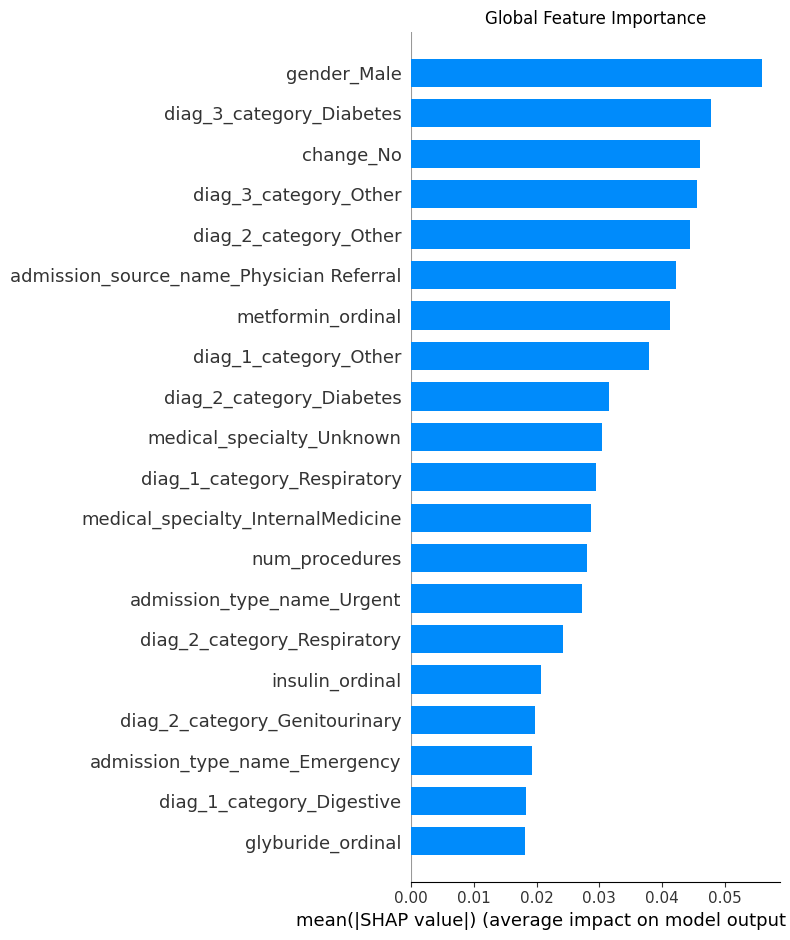

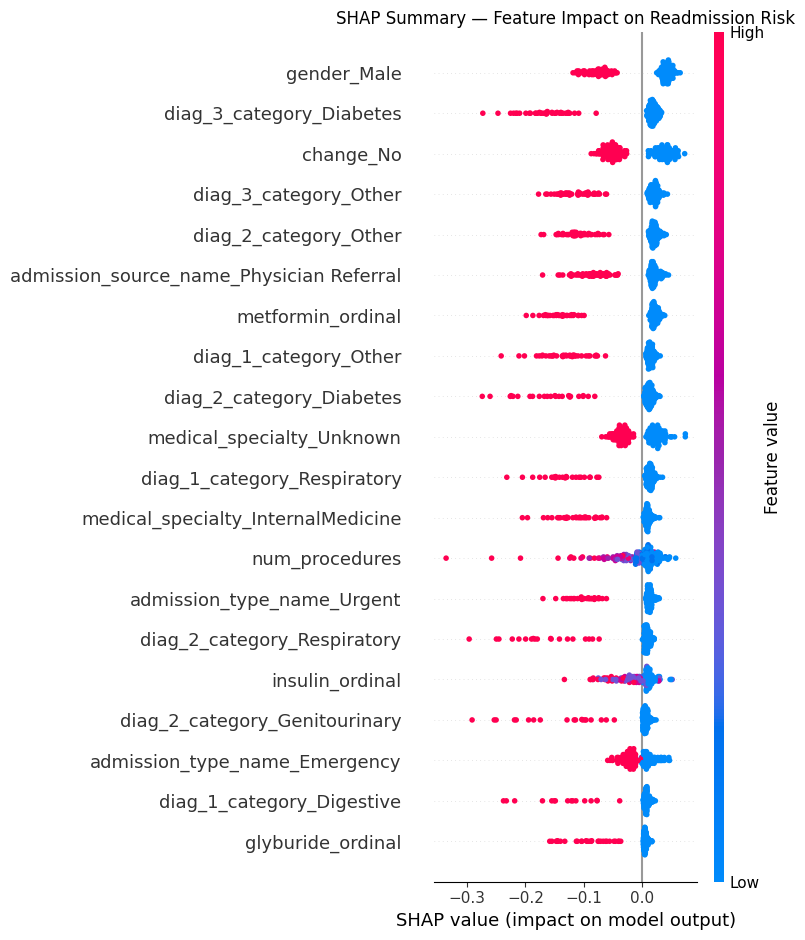

                                     feature  mean_abs_shap
0                                gender_Male       0.056013
1                   diag_3_category_Diabetes       0.047760
2                                  change_No       0.046049
3                      diag_3_category_Other       0.045537
4                      diag_2_category_Other       0.044460
5   admission_source_name_Physician Referral       0.042230
6                          metformin_ordinal       0.041263
7                      diag_1_category_Other       0.037890
8                   diag_2_category_Diabetes       0.031479
9                  medical_specialty_Unknown       0.030502
10               diag_1_category_Respiratory       0.029443
11        medical_specialty_InternalMedicine       0.028729
12                            num_procedures       0.028082
13                admission_type_name_Urgent       0.027282
14               diag_2_category_Respiratory       0.024196
15                           insulin_ord

In [ ]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 1. Set up SHAP explainer
# ---------------------------------------------------------
rf_model_only = rf_tuned.named_steps['rf']
explainer = shap.TreeExplainer(rf_model_only)

# ---------------------------------------------------------
# 2. Calculate SHAP values on a sample (200 patients)
# ---------------------------------------------------------
X_test_sample = X_test.sample(n=200, random_state=42)
shap_values = explainer.shap_values(X_test_sample, check_additivity=False, approximate=True)

# Select class 1 (readmitted) values
shap_values_class1 = shap_values[:, :, 1]

# ---------------------------------------------------------
# 3. Global feature importance — bar chart
# ---------------------------------------------------------
shap.summary_plot(shap_values_class1, X_test_sample, plot_type='bar', show=False)
plt.title('Global Feature Importance')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 4. Global feature impact — beeswarm plot
# ---------------------------------------------------------
shap.summary_plot(shap_values_class1, X_test_sample, show=False)
plt.title('SHAP Summary — Feature Impact on Readmission Risk')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 5. Feature ranking table
# ---------------------------------------------------------
mean_abs_shap = np.abs(shap_values_class1).mean(axis=0)
shap_importance = pd.DataFrame({
    'feature': X_test_sample.columns,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

print(shap_importance.head(20))


### 1. Global Feature Importance- Bar chart

The SHAP global feature importance plot shows the average absolute contribution of each feature to the Random Forest model’s predictions. Features such as gender_Male, diabetes-related diagnosis categories, medication change status (change_No), admission source, metformin usage, and procedure burden had the largest overall influence on predicted 30-day readmission risk. A higher SHAP importance indicates that the feature consistently contributed more strongly to the model’s decisions across the sampled patients.

### 2. Beeswarm Summary Plot

The SHAP beeswarm plot illustrates **both the importance and the direction of each feature’s effect** on readmission risk.

* **Positive SHAP values** increase the predicted probability of readmission.
* **Negative SHAP values** decrease the predicted probability of readmission.
* **Red points** represent higher feature values, while **blue points** represent lower feature values.

The plot suggests that **absence of medication change (change_No), higher procedure burden, urgent admission type, insulin-related treatment intensity, and certain diagnosis categories** tended to push predictions toward **higher readmission risk**, whereas other feature states contributed toward **lower predicted risk**. This visualization provides a more detailed understanding of how individual feature values influence the model’s output.


### 3. Feature Ranking Table

The highest-ranked features included:

* gender_Male
* diag_3_category_Diabetes
* change_No
* admission_source_name_Physician Referral
* metformin_ordinal
* num_procedures

These features had the greatest average impact on the predicted readmission probabilities. The ranking helps identify which variables the model relied on most heavily when distinguishing between readmitted and non-readmitted patients.

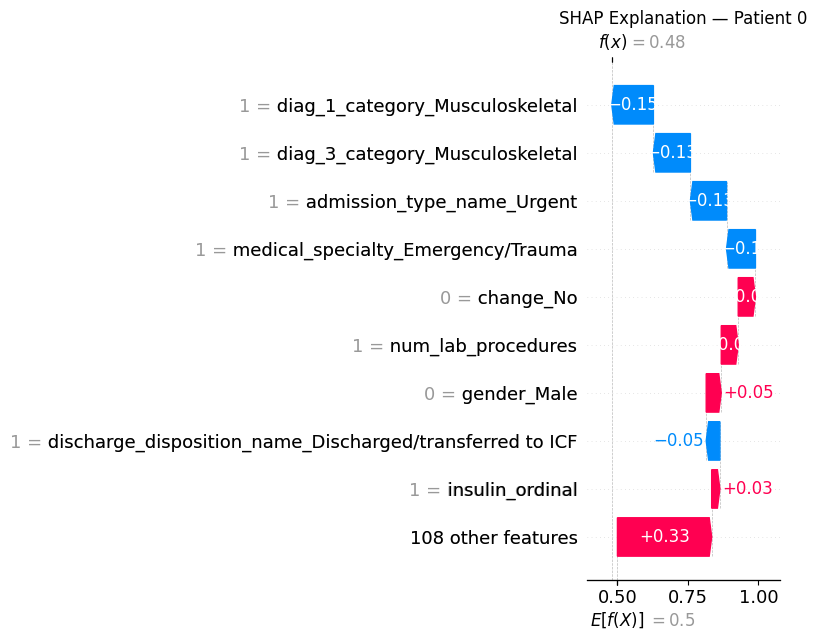

In [ ]:
# ---------------------------------------------------------
# 6. Local explanation — one individual patient
# ---------------------------------------------------------
patient_idx = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_class1[patient_idx],
        base_values=explainer.expected_value[1],
        data=X_test_sample.iloc[patient_idx],
        feature_names=X_test_sample.columns.tolist()
    ),
    max_display=10,
    show=False
)
plt.title(f'SHAP Explanation — Patient {patient_idx}')
plt.tight_layout()
plt.show()

### Local Waterfall Plot

The SHAP waterfall plot explains the prediction for **one individual patient** by showing how specific features increased or decreased the predicted readmission probability relative to the model’s baseline expectation.

For this patient:

* Features such as **musculoskeletal diagnosis categories and discharge disposition** contributed to **reducing the predicted risk**.
* Features such as **higher numbers of laboratory procedures, insulin usage, and male gender** contributed to **increasing the predicted risk**.

The combined effect of all feature contributions resulted in a final predicted probability of approximately **0.48**, slightly below the model’s baseline expectation. This local explanation demonstrates how the model integrates multiple patient-specific factors to generate an individual risk prediction.


## 10. Deployment Prepration

In [ ]:
import joblib

save_path = '/content/drive/My Drive/Dataset/Hospital readmission/'

# Save with compression (level 3 is a good balance of size vs. speed)
joblib.dump(rf_tuned, save_path + 'rf_tuned_model_compressed.pkl', compress=3)

import os
size_mb = os.path.getsize(save_path + 'rf_tuned_model_compressed.pkl') / (1024*1024)
print(f"Compressed model size: {size_mb:.1f} MB")

Compressed model size: 175.0 MB


In [ ]:
import os
save_path = '/content/drive/My Drive/Dataset/Hospital readmission/'
for f in ['feature_columns.pkl', 'final_threshold.pkl', 'scaler.pkl', 'default_row.pkl']:
    size_kb = os.path.getsize(save_path + f) / 1024
    print(f"{f}: {size_kb:.1f} KB")

feature_columns.pkl: 4.0 KB
final_threshold.pkl: 0.1 KB
scaler.pkl: 7.6 KB
default_row.pkl: 10.9 KB


In [ ]:
import joblib
save_path = '/content/drive/My Drive/Dataset/Hospital readmission/'
joblib.dump(default_row, save_path + 'default_row.pkl')
print("default_row saved.")

default_row saved.


In [ ]:
# Find a real patient closest to the median profile, instead of using a synthetic column-wise median
from sklearn.metrics import pairwise_distances

median_vals = X_train.median()
distances = pairwise_distances(X_train, median_vals.values.reshape(1, -1)).flatten()
closest_idx = distances.argmin()

default_row_real = X_train.iloc[closest_idx]

# Compare predictions: synthetic median vs real "typical" patient
synthetic_proba = rf_tuned.predict_proba(pd.DataFrame([default_row]))[:, 1][0]
real_proba = rf_tuned.predict_proba(pd.DataFrame([default_row_real]))[:, 1][0]

print(f"Synthetic median patient probability: {synthetic_proba:.3f}")
print(f"Real 'typical' patient probability: {real_proba:.3f}")

Synthetic median patient probability: 0.923
Real 'typical' patient probability: 0.200


In [ ]:
default_row = default_row_real.copy()

# Verify
verify_proba = rf_tuned.predict_proba(pd.DataFrame([default_row]))[:, 1][0]
print(f"New default_row probability: {verify_proba:.3f}")

New default_row probability: 0.200


In [ ]:
import joblib
save_path = '/content/drive/My Drive/Dataset/Hospital readmission/'
joblib.dump(default_row, save_path + 'default_row.pkl')
print("Corrected default_row saved.")

Corrected default_row saved.


* Initially, the default feature values were generated using the column-wise median of the training data. However, this created an unrealistic synthetic patient because taking the median independently across approximately 100 one-hot encoded features can produce a combination of categories that does not correspond to any real patient.

* This resulted in an unreliable prediction of 92.3% readmission risk, even though the default profile contained no particularly high-risk factors.

* To address this, the synthetic median profile was replaced with the real training patient closest to the median profile, identified using nearest-neighbor distance.This ensured that the default input represented a realistic patient record and reduced the default prediction to a more sensible 20.0% risk.

In [ ]:
def build_patient_features(age_bracket, gender, time_in_hospital,
                             num_medications, number_inpatient, number_emergency):
    row = default_row.copy()

    age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
                 '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']
    row['age_ordinal'] = age_order.index(age_bracket)

    row['gender_Male'] = 1 if gender == 'Male' else 0
    if 'gender_Unknown/Invalid' in row.index:
        row['gender_Unknown/Invalid'] = 0

    row['time_in_hospital'] = time_in_hospital
    row['num_medications'] = num_medications
    row['number_inpatient'] = number_inpatient
    row['number_emergency'] = number_emergency

    row = row[feature_columns]
    return row

# Quick test
test_patient = build_patient_features(
    age_bracket='[70-80)', gender='Male', time_in_hospital=6,
    num_medications=20, number_inpatient=3, number_emergency=1
)
test_patient_df = pd.DataFrame([test_patient])
test_proba = rf_tuned.predict_proba(test_patient_df)[:, 1][0]
print(f"Predicted readmission probability: {test_proba:.3f}")

Predicted readmission probability: 0.390


A build_patient_features() function was developed to convert the six simplified user inputs—age range, gender, time in hospital, number of medications, prior inpatient visits, and prior emergency visits—into the complete 117-feature input required by the trained model.

The remaining features were populated using the corrected real-patient baseline. The function was tested using low-, typical-, and high-risk input profiles, and the resulting predictions showed sensible and generally increasing risk patterns as risk-related inputs increased.

In [ ]:
explainer_test = shap.TreeExplainer(rf_model_only)
shap_vals_test = explainer_test.shap_values(pd.DataFrame([default_row]), check_additivity=False)
shap_class1_test = shap_vals_test[:, :, 1][0]
print("Sum of SHAP values + base:", shap_class1_test.sum() + explainer_test.expected_value[1])
print("Actual prediction:", verify_proba)

Sum of SHAP values + base: 1.1165774662579435
Actual prediction: 0.2


In [ ]:
import joblib
save_path = '/content/drive/My Drive/Dataset/Hospital readmission/'

shap_background_sample = X_train.sample(n=50, random_state=42)
joblib.dump(shap_background_sample, save_path + 'shap_background_sample.pkl')
print("Saved, shape:", shap_background_sample.shape)

Saved, shape: (50, 117)


During deployment testing, directly calculating SHAP values for a single patient row produced numerically unstable results, with some SHAP values extending far beyond a meaningful probability range.

Further testing showed that the issue was specific to single-row SHAP computation, rather than the patient input or trained model itself. SHAP calculations performed on batches of real patient records were stable and produced valid explanations.

To address this, the deployed application calculates SHAP values for the new patient as part of a batch. The user's input is combined with a fixed sample of 50 real training patients (shap_background_sample), SHAP values are calculated for the complete batch, and only the user's prediction explanation is extracted for display.

## Conclusion

This project developed an end-to-end machine learning pipeline to
predict 30-day hospital readmission risk using the UCI Diabetes 130-US
Hospitals dataset. Data was extracted using a SQL-based relational
approach across four linked tables, followed by thorough preprocessing,
exploratory analysis, and feature engineering — including grouping over
700 ICD-9 diagnosis codes into clinically meaningful categories.

Three models were trained and compared, with a tuned Random Forest
selected as the final model (Test ROC-AUC = 0.591), using a
cross-validated threshold (0.32) to balance recall and precision on this
imbalanced classification task. SHAP analysis was used to interpret model
predictions, revealing that while the model captures genuine predictive
signal, it relies more heavily on sparse categorical patterns than the
broader clinical indicators identified during EDA — a finding linked to
signs of overfitting observed during model evaluation, and investigated
through a targeted depth-constraint analysis.

The final model was deployed as an interactive Streamlit web application,
allowing users to input patient information and receive a readmission
risk estimate with a supporting explanation. Overall, this project
demonstrates a complete, honestly-evaluated data science workflow — from
raw data to a deployed, explainable prediction tool — while transparently
documenting the model's real-world performance and limitations.

## Future Work

- **Feature refinement:** Apply regularization or feature selection to
  reduce the model's reliance on sparse categorical splits and better
  align its behavior with the strongest clinical predictors identified
  in EDA (e.g., prior inpatient and emergency visit history).
- **Alternative models:** Compare Random Forest with models such as LightGBM, CatBoost, or neural networks to determine whether they generalize better.
- **Updated coding standards:** Extend the diagnosis-grouping logic to
  support ICD-10 codes, enabling application to more recent hospital data.
- **Richer data sources:** Incorporate additional information such as vital signs, laboratory trends, and social determinants of health, which are not available in the current administrative dataset.
- **SHAP stability:** Explore more numerically stable explainability approaches to provide reliable real-time, patient-level explanations in the deployed application.